# GNN pipeline for protein mutation ΔΔG

This notebook builds a GNN pipeline to predict how a single amino acid mutation changes protein stability. The target is ΔΔG in kcal/mol. Negative and positive values mean the mutation changes stability in different directions, and large-magnitude values are harder to predict because they are rare.

The main idea:

`single mutation row --> find the protein structure --> build a local residue graph around the mutation --> make a wild-type graph and a mutant graph --> run both graphs through the same GNN --> compare the mutation-site embeddings --> predict ΔΔG`


With Jargon: 
`mutant embedding - WT embedding --> add engineered mutation/condition features --> regression head --> predicted ΔΔG`

## 0. Imports and setup

`ALLOW_STRUCTURE_DOWNLOADS=True` tells the graph builder to try real PDB or AlphaFold structures before falling back to a sequence-neighborhood graph.

In [1]:
# control flags
RUN_FULL_TRAINING = True
LOAD_SAVED_RESULTS = False
SAVE_RESULTS = True
SAVE_FIGURES = True

In [2]:
# kernel check
import sys
print(sys.executable)
print(sys.version)

import torch
import torch_geometric

print("torch:", torch.__version__)
print("torch_geometric:", torch_geometric.__version__)
print("mps available:", torch.backends.mps.is_available() if hasattr(torch.backends, "mps") else False)

/Users/zoyakhan/Documents/GitHub/aml-final-project/.venv_gnn/bin/python
3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:54:21) [Clang 16.0.6 ]


/Users/zoyakhan/Documents/GitHub/aml-final-project/.venv_gnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.11.0
torch_geometric: 2.7.0
mps available: False


In [3]:
import os
import re
import json
import math
import random
import pickle
import warnings
import hashlib
from pathlib import Path
from collections import Counter

CACHE_DIR = Path("gnn_cache")
MPL_CACHE = CACHE_DIR / "matplotlib"
MPL_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import numpy as np
import pandas as pd
import matplotlib
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, ElasticNetCV, LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.exceptions import ConvergenceWarning

try:
    import requests
    from Bio.PDB import PDBParser
    from Bio.Align import substitution_matrices
except Exception as e:
    requests = None
    PDBParser = None
    substitution_matrices = None
    print("Optional structure/BLOSUM imports failed:", repr(e))

from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

warnings.filterwarnings("ignore", category=ConvergenceWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_PATH = Path("single_point_mutations.tsv")
PDB_DIR = CACHE_DIR / "pdb_files"
PARSED_CACHE = CACHE_DIR / "parsed_structures_v2"
GRAPH_CACHE_ROOT = CACHE_DIR / "graph_examples_v7"
for p in [CACHE_DIR, PDB_DIR, PARSED_CACHE, GRAPH_CACHE_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

ALLOW_STRUCTURE_DOWNLOADS = True
MAX_NEW_STRUCTURE_DOWNLOADS = 150
USE_SEQUENCE_FALLBACK = True
CONTACT_CUTOFF = 8.0
STRUCTURE_LOCAL_RADIUS_A = 12.0
STRUCTURE_LOCAL_MAX_NEIGHBORS = 64
SEQUENCE_WINDOW = 2
LOCAL_SEQUENCE_RADIUS = 32
RBF_CENTERS = np.linspace(0.0, 20.0, 8).astype(np.float32)
RBF_GAMMA = 0.08
EDGE_DIM = len(RBF_CENTERS) + 3
GRAPH_CACHE_MODE = "structure_downloads_on_v7" if ALLOW_STRUCTURE_DOWNLOADS else "sequence_fallback_only_v7"
GRAPH_CACHE = GRAPH_CACHE_ROOT / GRAPH_CACHE_MODE
GRAPH_CACHE.mkdir(parents=True, exist_ok=True)

HIDDEN_DIM = 48
NUM_LAYERS = 2
DROPOUT = 0.20
LR = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 32
MAX_EPOCHS = 45
PATIENCE = 8
OVERFIT_EPOCHS = 250
GNN_SEEDS = [42, 43, 44]
RUN_GNN_COMPARISON = True
RUN_PERMUTATION_CHECK = False
STRUCTURE_MIN_COUNTS = {"train": 30, "val": 10, "test": 10}
STRUCTURE_PREFETCH_SPLIT_ORDER = ["val", "test", "train"]

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)
print("Data path exists:", DATA_PATH.exists())
print("Structure downloads enabled:", ALLOW_STRUCTURE_DOWNLOADS, "max new downloads:", MAX_NEW_STRUCTURE_DOWNLOADS)
print("Graph cache mode:", GRAPH_CACHE_MODE)
print("Edge feature dimension:", EDGE_DIM)


Using device: cpu
Data path exists: True
Structure downloads enabled: True max new downloads: 150
Graph cache mode: structure_downloads_on_v7
Edge feature dimension: 11


In [4]:
RESULTS_DIR = Path("results")
FIGURES_DIR = Path("assets")
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

RUN_TAG = "final_main"   
SAVE_RESULTS = True
SAVE_FIGURES = True
RUN_DEBUG_OVERFIT = False

## 1. Load data and confirm the target

Here we load `single_point_mutations.tsv` and confirm what the model is trying to predict. The target is `∆∆G_(kcal/mol)`.

This section also extracts the wild-type amino acid, mutation position, mutant amino acid, pH, temperature, ASA, and a stricter protein identifier called `protein_group`.

The `protein_group` field is important because protein names are messy. The same real protein can appear under slightly different display names. To reduce leakage, we group by valid UniProt ID first, then valid PDB ID, then the display protein name only if no better identifier exists.

**Results**

The cleaned dataset kept `2516` usable mutation rows out of `2531`, so very little data was lost during basic cleaning. The target spans a wide range, from about `-23.21` to `12.70` kcal/mol, which tells us there are a few extreme mutations that can strongly affect RMSE. The dataset has `86` protein groups, so splitting by protein group is possible.

In [5]:
TARGET_COL = "∆∆G_(kcal/mol)"
MUTATION_RE = re.compile(r"^\s*([A-Z])(\d+)([A-Z])")
FLOAT_RE = re.compile(r"[-+]?\d*\.?\d+")

def parse_mutation(text):
    if not isinstance(text, str):
        return None, None, None
    m = MUTATION_RE.match(text)
    if m is None:
        return None, None, None
    return m.group(1), int(m.group(2)), m.group(3)

def parse_first_float(value):
    if pd.isna(value):
        return np.nan
    m = FLOAT_RE.search(str(value))
    return float(m.group(0)) if m else np.nan

def is_valid_uniprot(value):
    s = str(value).strip()
    return bool(s) and s.lower() != "nan" and s != "-"

def is_valid_pdb(value):
    s = str(value).strip()
    return bool(re.fullmatch(r"[A-Za-z0-9]{4}", s))

def mutation_basis(text):
    s = str(text)
    if "UniProt" in s:
        return "uniprot"
    if "PDB" in s:
        return "pdb"
    if "Paper" in s:
        return "paper"
    return "unknown"

def canonical_protein_group(row):
    if is_valid_uniprot(row["UniProt_ID"]):
        return "UP:" + str(row["UniProt_ID"]).strip()
    if is_valid_pdb(row["PDB_wild"]):
        return "PDB:" + str(row["PDB_wild"]).strip().upper()
    return "PROT:" + str(row["PROTEIN"]).strip()

raw_df = pd.read_csv(DATA_PATH, sep="\t")
print("Raw shape:", raw_df.shape)
print("Columns:")
print(raw_df.columns.tolist())
display(raw_df.head(3))

required = ["PROTEIN", "UniProt_ID", "MUTATION", "PDB_wild", "PDB_Chain_Mutation", "pH", "T_(C)", "ASA", TARGET_COL]
missing = [c for c in required if c not in raw_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = raw_df.copy()
df["ddG"] = pd.to_numeric(df[TARGET_COL], errors="coerce")
parsed = df["MUTATION"].apply(parse_mutation)
df["WT_AA"] = parsed.apply(lambda x: x[0])
df["POSITION"] = parsed.apply(lambda x: x[1])
df["MUT_AA"] = parsed.apply(lambda x: x[2])
df["pH_num"] = df["pH"].apply(parse_first_float)
df["temp_C_num"] = df["T_(C)"].apply(parse_first_float)
df["ASA_num"] = pd.to_numeric(df["ASA"], errors="coerce")
df["pH_missing"] = df["pH_num"].isna().astype(int)
df["temp_missing"] = df["temp_C_num"].isna().astype(int)
df["ASA_missing"] = df["ASA_num"].isna().astype(int)
df["mutation_basis"] = df["MUTATION"].apply(mutation_basis)

before = len(df)
df = df.dropna(subset=["ddG", "WT_AA", "POSITION", "MUT_AA", "PROTEIN"]).copy()
df["POSITION"] = df["POSITION"].astype(int)
df["protein_group"] = df.apply(canonical_protein_group, axis=1)
df["mutation_key"] = (
    df["protein_group"].astype(str) + ":" + df["WT_AA"].astype(str)
    + df["POSITION"].astype(str) + df["MUT_AA"].astype(str)
)
df["row_id"] = np.arange(len(df))

print(f"Rows after target/mutation/protein cleaning: {len(df)} / {before}")
print("Target column:", TARGET_COL)
print("Target summary:")
display(df["ddG"].describe())
print("Unique display proteins:", df["PROTEIN"].nunique())
print("Unique protein groups:", df["protein_group"].nunique())
print("Mutation basis counts:")
print(df["mutation_basis"].value_counts())
display(df[["PROTEIN", "UniProt_ID", "PDB_wild", "protein_group", "MUTATION", "WT_AA", "POSITION", "MUT_AA", "ddG", "pH_num", "temp_C_num", "ASA_num"]].head(10))


Raw shape: (2531, 19)
Columns:
['NO', 'PROTEIN', 'UniProt_ID', 'MUTATION', 'SOURCE', 'PDB_wild', 'PDB_Chain_Mutation', 'SEC_STR', 'ASA', 'pH', 'T_(C)', '∆∆G_(kcal/mol)', '∆∆G_H2O_(kcal/mol)', 'STATE', 'REVERSIBILITY', 'PubMed_ID', 'KEY_WORDS', 'REFERENCE', 'AUTHOR']


,NO,PROTEIN,UniProt_ID,MUTATION,SOURCE,PDB_wild,PDB_Chain_Mutation,SEC_STR,ASA,pH,T_(C),∆∆G_(kcal/mol),∆∆G_H2O_(kcal/mol),STATE,REVERSIBILITY,PubMed_ID,KEY_WORDS,REFERENCE,AUTHOR
0,176,Villin-1,P02640,D44N (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,-,1.73,-,-,-,33779182.0,Ferritin; nativs-side chain;Xa,"J Phys Chem B 125, 3269-3277 (2021) PMID: 3377...","Zou J, Xiao S, Simmerling C, Raleigh DP"
1,177,Villin-1,P02640,E795Q (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,-,1.9,-,-,-,33779182.0,Ferritin; nativs-side chain;Xa,"J Phys Chem B 125, 3269-3277 (2021) PMID: 3377...","Zou J, Xiao S, Simmerling C, Raleigh DP"
2,178,Villin-1,P02640,D796N (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,-,1.61,-,-,-,33779182.0,Ferritin; nativs-side chain;Xa,"J Phys Chem B 125, 3269-3277 (2021) PMID: 3377...","Zou J, Xiao S, Simmerling C, Raleigh DP"


Rows after target/mutation/protein cleaning: 2516 / 2531
Target column: ∆∆G_(kcal/mol)
Target summary:


count    2516.000000
mean       -0.560848
std         1.836260
min       -23.210000
25%        -1.322500
50%        -0.300000
75%         0.372500
max        12.700000
Name: ddG, dtype: float64

Unique display proteins: 89
Unique protein groups: 86
Mutation basis counts:
mutation_basis
pdb        1808
uniprot     497
paper       211
Name: count, dtype: int64


,PROTEIN,UniProt_ID,PDB_wild,protein_group,MUTATION,WT_AA,POSITION,MUT_AA,ddG,pH_num,temp_C_num,ASA_num
0,Villin-1,P02640,1YRF,UP:P02640,D44N (UniProt),D,44,N,1.730000,3.0,NaN,NaN
1,Villin-1,P02640,1YRF,UP:P02640,E795Q (UniProt),E,795,Q,1.900000,3.0,NaN,NaN
2,Villin-1,P02640,1YRF,UP:P02640,D796N (UniProt),D,796,N,1.610000,3.0,NaN,NaN
3,Villin-1,P02640,1YRF,UP:P02640,E822Q (UniProt),E,822,Q,1.600000,3.0,NaN,NaN
4,Villin-1,P02640,1YRF,UP:P02640,D44N (UniProt),D,44,N,-0.460000,6.0,NaN,NaN
5,Villin-1,P02640,1YRF,UP:P02640,E795Q (UniProt),E,795,Q,-0.400000,6.0,NaN,NaN
6,Villin-1,P02640,1YRF,UP:P02640,D796N (UniProt),D,796,N,-0.880000,6.0,NaN,NaN
7,Villin-1,P02640,1YRF,UP:P02640,E822Q (UniProt),E,822,Q,-0.100000,6.0,NaN,NaN
8,Class A sortase SrtA,Q9S446,1T2P,UP:Q9S446,M155V (UniProt),M,155,V,2.007650,7.5,NaN,NaN
9,Class A sortase SrtA,Q9S446,1T2P,UP:Q9S446,V193R (UniProt),V,193,R,2.318358,7.5,NaN,NaN


## 2. Data quality, duplicate, outlier, and leakage diagnostics

This section checks three things:

- Outliers: very large `|ΔΔG|` values that may dominate RMSE.
- Replicates: repeated mutation measurements that show the noise floor of the dataset.
- Identifier issues: proteins with multiple names, which can cause accidental leakage if we split carelessly

**Results**

There are only `6` very large `|ΔΔG| > 10` outliers. The duplicate/replicate checks show that the same mutation can have noticeably different measured ΔΔG values. The estimated replicate noise floor is around `0.4-0.5` RMSE, so we should not expect a small notebook model to reach near-zero error on this dataset.

In [6]:
outliers = df[df["ddG"].abs() > 10].copy()
print(f"Rows with |ddG| > 10: {len(outliers)}")
if len(outliers):
    display(outliers[["PROTEIN", "UniProt_ID", "PDB_wild", "MUTATION", "ddG", "pH", "T_(C)", "REFERENCE"]].sort_values("ddG"))

mutation_reps = (
    df.groupby("mutation_key")["ddG"]
    .agg(count="count", mean="mean", std="std", min="min", max="max")
    .query("count > 1")
    .sort_values(["count", "std"], ascending=False)
)
print(f"Mutation groups with replicate rows: {len(mutation_reps)}")
display(mutation_reps.head(15))

condition_key = ["mutation_key", "pH_num", "temp_C_num"]
condition_reps = (
    df.groupby(condition_key, dropna=False)["ddG"]
    .agg(count="count", mean="mean", std="std", min="min", max="max")
    .query("count > 1")
    .sort_values(["count", "std"], ascending=False)
)
print(f"Mutation+condition groups with replicate rows: {len(condition_reps)}")
display(condition_reps.head(15))

def replicate_noise_floor(frame, group_cols):
    gmean = frame.groupby(group_cols, dropna=False)["ddG"].transform("mean")
    counts = frame.groupby(group_cols, dropna=False)["ddG"].transform("count")
    mask = counts > 1
    if mask.sum() == 0:
        return np.nan, 0
    rmse = float(np.sqrt(np.mean((frame.loc[mask, "ddG"] - gmean.loc[mask]) ** 2)))
    return rmse, int(mask.sum())

mut_noise, mut_noise_n = replicate_noise_floor(df, ["mutation_key"])
cond_noise, cond_noise_n = replicate_noise_floor(df, condition_key)
print(f"Approx replicate noise floor by mutation only: RMSE={mut_noise:.3f} over {mut_noise_n} rows")
print(f"Approx replicate noise floor by mutation+pH+temp: RMSE={cond_noise:.3f} over {cond_noise_n} rows")

print("\nIdentifier synonyms that motivated protein_group:")
uid_syn = df.groupby("UniProt_ID")["PROTEIN"].nunique().sort_values(ascending=False)
display(uid_syn[uid_syn > 1].head(15).to_frame("display_name_count"))


Rows with |ddG| > 10: 6


,PROTEIN,UniProt_ID,PDB_wild,MUTATION,ddG,pH,T_(C),REFERENCE
123,Beta-glucosidase,O61594,5CG0,N391A (PDB: N391A),-23.21,6.0,-,FEBS J. (2016) Mar;283(6):1124-38 PMID: 26785700
273,Tailspike protein,P12528,1CLW,R383S (UniProt),-17.40,7.4,88.4,"J BIOL CHEM 264, 10693-10698 (1989) PMID: 2525128"
829,Ribonuclease pancreatic,P61823,1RTB,Y123A (PDB: Y97A),-12.00,5.0,63.3,"PROTEIN SCI 5, 1697-1703 (1996) PMID: 8844858"
830,Ribonuclease pancreatic,P61823,1RTB,Y123G (PDB: Y97G),-11.70,5.0,63.3,"PROTEIN SCI 5, 1697-1703 (1996) PMID: 8844858"
271,Tailspike protein,P12528,1CLW,R286K (UniProt),-10.30,7.4,88.4,"J BIOL CHEM 264, 10693-10698 (1989) PMID: 2525128"
462,Superoxide dismutase [Mn],P04179,1N0J,Y58F (PDB: Y34F),12.70,7.8,70,"BIOCHEMISTRY 37, 4722-4730 (1998) PMID: 9537987"


Mutation groups with replicate rows: 467


,count,mean,std,min,max
mutation_key,,,,,
UP:P32081:E3R,26,1.661923,0.591730,0.76,2.66
UP:P32081:S48K,15,0.724000,0.212865,0.48,1.42
PROT:Cold shock protein B; synthetic:E50K,12,0.103333,0.292585,-0.26,0.45
PROT:Cold shock protein B; synthetic:K5Q,12,-0.551667,0.180345,-0.84,-0.29
PROT:Cold shock protein B; synthetic:K20V,12,2.185833,0.104573,2.06,2.39
UP:P32081:M1R,10,1.227000,0.450655,0.82,1.75
UP:P32081:E43S,10,0.203000,0.083407,0.10,0.29
UP:P00720:A82P,9,0.547778,0.381568,-0.07,1.27
UP:P22069:M23L,9,-2.531111,0.224747,-2.89,-2.22


Mutation+condition groups with replicate rows: 197


,,,count,mean,std,min,max
mutation_key,pH_num,temp_C_num,,,,,
UP:P32081:E3R,7.5,55.0,18,1.723889,0.444630,0.98,2.41
PROT:Cold shock protein B; synthetic:E50K,7.5,55.0,12,0.103333,0.292585,-0.26,0.45
PROT:Cold shock protein B; synthetic:K5Q,7.5,55.0,12,-0.551667,0.180345,-0.84,-0.29
PROT:Cold shock protein B; synthetic:K20V,7.5,55.0,12,2.185833,0.104573,2.06,2.39
UP:P32081:S48K,7.5,55.0,12,0.673333,0.099117,0.48,0.81
UP:P32081:M1R,7.0,NaN,9,1.170000,0.438092,0.82,1.75
PROT:Cold shock protein B; synthetic:E48K,7.5,55.0,9,-1.166667,0.219716,-1.39,-0.79
UP:P32081:E43S,7.0,NaN,9,0.193333,0.082310,0.10,0.29
PROT:Cold shock protein B; synthetic:K5E,7.5,55.0,7,-1.207143,0.509893,-1.91,-0.65


Approx replicate noise floor by mutation only: RMSE=0.495 over 1491 rows
Approx replicate noise floor by mutation+pH+temp: RMSE=0.418 over 722 rows

Identifier synonyms that motivated protein_group:


,display_name_count
UniProt_ID,
-,3
P32081,3
P05798,3
P00974,2
P62593,2
P05230,2
P00651,2
P00644,2
P02625,2


## 3. Strict protein-group train/validation/test split

The main split is by `protein_group`, not by individual rows.

Why this matters:

`random row split --> same protein can appear in train and test --> model may memorize protein-specific patterns`

`protein_group split --> each protein group goes to only one split --> test set better measures generalization to unseen proteins`

The code also checks for overlap by UniProt ID, PDB ID, and mutation key. Ideally, all overlap counts are zero. If any overlap appears, the model may be getting an unfair advantage.


**Result Interpretation**

The split produced `1509` training rows, `504` validation rows, and `503` test rows.

In [7]:
def greedy_group_split(frame, group_col="protein_group", train_frac=0.60, val_frac=0.20, seed=SEED):
    rng = np.random.default_rng(seed)
    groups = frame.groupby(group_col).agg(n=("ddG", "size"), mean_ddG=("ddG", "mean")).reset_index()
    groups["jitter"] = rng.random(len(groups))
    groups = groups.sort_values(["n", "jitter"], ascending=[False, True])
    desired = {
        "train": train_frac * len(frame),
        "val": val_frac * len(frame),
        "test": (1.0 - train_frac - val_frac) * len(frame),
    }
    current = {"train": 0, "val": 0, "test": 0}
    assignment = {}
    for _, row in groups.iterrows():
        # Use normalized remaining capacity so the largest groups preferentially fill train.
        remaining = {k: (desired[k] - current[k]) / max(desired[k], 1) for k in current}
        split = max(remaining, key=remaining.get)
        assignment[row[group_col]] = split
        current[split] += int(row["n"])
    return frame[group_col].map(assignment)

df["split"] = greedy_group_split(df)
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "val"].copy()
test_df = df[df["split"] == "test"].copy()

print("Rows by split before graph construction:")
print(df["split"].value_counts())
print("\nProtein groups by split:")
print(df.groupby("split")["protein_group"].nunique())
print("\nLabel distribution before graph construction:")
display(df.groupby("split")["ddG"].agg(["count", "mean", "std", "min", "max"]))

sets = {name: set(df.loc[df.split == name, "protein_group"]) for name in ["train", "val", "test"]}
print("\nprotein_group overlap train/val:", len(sets["train"] & sets["val"]))
print("protein_group overlap train/test:", len(sets["train"] & sets["test"]))
print("protein_group overlap val/test:", len(sets["val"] & sets["test"]))

def cross_split_report(frame, cols):
    g = frame.dropna(subset=cols).groupby(cols)["split"].nunique()
    crossing = g[g > 1]
    print(f"Cross-split groups by {cols}: {len(crossing)}")
    if len(crossing):
        display(crossing.head(10).to_frame("n_splits"))

cross_split_report(df[df["UniProt_ID"].map(is_valid_uniprot)], ["UniProt_ID"])
cross_split_report(df[df["PDB_wild"].map(is_valid_pdb)], ["PDB_wild"])
cross_split_report(df, ["mutation_key"])

TARGET_MEAN = float(train_df["ddG"].mean())
TARGET_STD = float(train_df["ddG"].std(ddof=0))
if TARGET_STD < 1e-8:
    raise ValueError("Training target has near-zero standard deviation.")
print(f"\nTarget scaling from train only: mean={TARGET_MEAN:.4f}, std={TARGET_STD:.4f}")


Rows by split before graph construction:
split
train    1509
val       504
test      503
Name: count, dtype: int64

Protein groups by split:
split
test     16
train    53
val      17
Name: protein_group, dtype: int64

Label distribution before graph construction:


,count,mean,std,min,max
split,,,,,
test,503,-0.377066,1.735929,-8.40,6.80
train,1509,-0.791750,1.926016,-23.21,12.70
val,504,-0.052937,1.509419,-5.38,6.93



protein_group overlap train/val: 0
protein_group overlap train/test: 0
protein_group overlap val/test: 0
Cross-split groups by ['UniProt_ID']: 0
Cross-split groups by ['PDB_wild']: 0
Cross-split groups by ['mutation_key']: 0

Target scaling from train only: mean=-0.7917, std=1.9254


## 4. Amino acid, condition, and tabular feature helpers

The model uses two kinds of information.

First, each residue node gets features such as amino acid identity, hydrophobicity, charge, molecular weight, volume, whether it is the mutation site, graph degree, and distance to the mutation site when 3D coordinates are available.

Second, each mutation gets engineered features such as WT amino acid properties, mutant amino acid properties, property differences, BLOSUM62 score, mutation-site contact count, and experimental condition features like pH, temperature, and ASA.

The tabular baselines use these engineered features without a graph. 

In [8]:
AA_LIST = list("ARNDCQEGHILKMFPSTWYV")
AA_TO_IDX = {aa: i for i, aa in enumerate(AA_LIST)}

AA_PROPS = {
    "A": dict(hydrophobicity=1.8,  weight=89.09,  volume=88.6,  charge=0, polarity=0, aromatic=0, sulfur=0, proline=0, glycine=0),
    "R": dict(hydrophobicity=-4.5, weight=174.20, volume=173.4, charge=1, polarity=1, aromatic=0, sulfur=0, proline=0, glycine=0),
    "N": dict(hydrophobicity=-3.5, weight=132.12, volume=114.1, charge=0, polarity=1, aromatic=0, sulfur=0, proline=0, glycine=0),
    "D": dict(hydrophobicity=-3.5, weight=133.10, volume=111.1, charge=-1, polarity=1, aromatic=0, sulfur=0, proline=0, glycine=0),
    "C": dict(hydrophobicity=2.5,  weight=121.15, volume=108.5, charge=0, polarity=0, aromatic=0, sulfur=1, proline=0, glycine=0),
    "Q": dict(hydrophobicity=-3.5, weight=146.15, volume=143.8, charge=0, polarity=1, aromatic=0, sulfur=0, proline=0, glycine=0),
    "E": dict(hydrophobicity=-3.5, weight=147.13, volume=138.4, charge=-1, polarity=1, aromatic=0, sulfur=0, proline=0, glycine=0),
    "G": dict(hydrophobicity=-0.4, weight=75.07,  volume=60.1,  charge=0, polarity=0, aromatic=0, sulfur=0, proline=0, glycine=1),
    "H": dict(hydrophobicity=-3.2, weight=155.16, volume=153.2, charge=0.1, polarity=1, aromatic=1, sulfur=0, proline=0, glycine=0),
    "I": dict(hydrophobicity=4.5,  weight=131.17, volume=166.7, charge=0, polarity=0, aromatic=0, sulfur=0, proline=0, glycine=0),
    "L": dict(hydrophobicity=3.8,  weight=131.17, volume=166.7, charge=0, polarity=0, aromatic=0, sulfur=0, proline=0, glycine=0),
    "K": dict(hydrophobicity=-3.9, weight=146.19, volume=168.6, charge=1, polarity=1, aromatic=0, sulfur=0, proline=0, glycine=0),
    "M": dict(hydrophobicity=1.9,  weight=149.21, volume=162.9, charge=0, polarity=0, aromatic=0, sulfur=1, proline=0, glycine=0),
    "F": dict(hydrophobicity=2.8,  weight=165.19, volume=189.9, charge=0, polarity=0, aromatic=1, sulfur=0, proline=0, glycine=0),
    "P": dict(hydrophobicity=-1.6, weight=115.13, volume=112.7, charge=0, polarity=0, aromatic=0, sulfur=0, proline=1, glycine=0),
    "S": dict(hydrophobicity=-0.8, weight=105.09, volume=89.0,  charge=0, polarity=1, aromatic=0, sulfur=0, proline=0, glycine=0),
    "T": dict(hydrophobicity=-0.7, weight=119.12, volume=116.1, charge=0, polarity=1, aromatic=0, sulfur=0, proline=0, glycine=0),
    "W": dict(hydrophobicity=-0.9, weight=204.24, volume=227.8, charge=0, polarity=0, aromatic=1, sulfur=0, proline=0, glycine=0),
    "Y": dict(hydrophobicity=-1.3, weight=181.19, volume=193.6, charge=0, polarity=1, aromatic=1, sulfur=0, proline=0, glycine=0),
    "V": dict(hydrophobicity=4.2,  weight=117.15, volume=140.0, charge=0, polarity=0, aromatic=0, sulfur=0, proline=0, glycine=0),
}
PROP_NAMES = ["hydrophobicity", "weight", "volume", "charge", "polarity", "aromatic", "sulfur", "proline", "glycine"]

THREE_TO_ONE = {
    "ALA":"A", "ARG":"R", "ASN":"N", "ASP":"D", "CYS":"C", "GLN":"Q", "GLU":"E", "GLY":"G", "HIS":"H", "ILE":"I",
    "LEU":"L", "LYS":"K", "MET":"M", "PHE":"F", "PRO":"P", "SER":"S", "THR":"T", "TRP":"W", "TYR":"Y", "VAL":"V",
}

try:
    BLOSUM62 = substitution_matrices.load("BLOSUM62") if substitution_matrices is not None else None
except Exception:
    BLOSUM62 = None

def aa_one_hot(aa):
    v = np.zeros(len(AA_LIST), dtype=np.float32)
    if aa in AA_TO_IDX:
        v[AA_TO_IDX[aa]] = 1.0
    return v

def prop_vector(aa):
    if aa not in AA_PROPS:
        return np.zeros(9, dtype=np.float32)
    p = AA_PROPS[aa]
    return np.array([
        p["hydrophobicity"] / 5.0,
        p["weight"] / 220.0,
        p["volume"] / 230.0,
        p["charge"],
        p["polarity"],
        p["aromatic"],
        p["sulfur"],
        p["proline"],
        p["glycine"],
    ], dtype=np.float32)

def blosum62_score(a, b):
    if BLOSUM62 is None or a not in AA_TO_IDX or b not in AA_TO_IDX:
        return 0.0
    try:
        return float(BLOSUM62[a, b]) / 10.0
    except Exception:
        try:
            return float(BLOSUM62[b, a]) / 10.0
        except Exception:
            return 0.0

def condition_vector(row):
    pH = row.get("pH_num", np.nan)
    temp = row.get("temp_C_num", np.nan)
    asa = row.get("ASA_num", np.nan)
    pH_missing = 1.0 if pd.isna(pH) else 0.0
    temp_missing = 1.0 if pd.isna(temp) else 0.0
    asa_missing = 1.0 if pd.isna(asa) else 0.0
    pH_scaled = 0.0 if pd.isna(pH) else (float(pH) - 7.0) / 7.0
    temp_scaled = 0.0 if pd.isna(temp) else (float(temp) - 25.0) / 50.0
    asa_scaled = 0.0 if pd.isna(asa) else float(asa) / 100.0
    return np.array([pH_scaled, temp_scaled, asa_scaled, pH_missing, temp_missing, asa_missing], dtype=np.float32)

CONDITION_FEATURE_NAMES = ["pH_scaled", "temp_scaled", "ASA_scaled", "pH_missing", "temp_missing", "ASA_missing"]

def node_features(seq, mut_idx, contact_counts=None, distances_to_site=None):
    n = len(seq)
    if contact_counts is None:
        contact_counts = np.zeros(n, dtype=np.float32)
    if distances_to_site is None:
        distances_to_site = np.full(n, np.nan, dtype=np.float32)
    max_seq_dist = max(1, n - 1)
    rows = []
    for i, aa in enumerate(seq):
        pos_norm = 0.0 if n <= 1 else i / (n - 1)
        seq_dist_norm = abs(i - mut_idx) / max_seq_dist
        is_site = 1.0 if i == mut_idx else 0.0
        contact_norm = float(contact_counts[i]) / 50.0
        d3 = distances_to_site[i]
        d3_norm = 0.0 if not np.isfinite(d3) else min(float(d3) / 40.0, 2.0)
        rows.append(np.concatenate([
            aa_one_hot(aa),
            prop_vector(aa),
            np.array([pos_norm, is_site, seq_dist_norm, contact_norm, d3_norm], dtype=np.float32),
        ]))
    return np.stack(rows).astype(np.float32)

NODE_DIM = len(AA_LIST) + 9 + 5
print("NODE_DIM:", NODE_DIM)

def edge_features(distance, seq_sep=None, is_sequence_edge=0.0):
    d = float(distance)
    rbf = np.exp(-RBF_GAMMA * (RBF_CENTERS - d) ** 2)
    inv_d = 1.0 / max(d, 1e-3)
    seq_sep_norm = 0.0 if seq_sep is None else min(abs(float(seq_sep)) / 64.0, 2.0)
    return np.concatenate([rbf, np.array([inv_d, seq_sep_norm, float(is_sequence_edge)], dtype=np.float32)]).astype(np.float32)

def base_mutation_feature_vector(wt_aa, mut_aa, mut_idx, edge_index=None, seq=None):
    wt = prop_vector(wt_aa)
    mut = prop_vector(mut_aa)
    delta = mut - wt
    site_degree = 0.0
    neigh_hydro = neigh_charge = neigh_volume = 0.0
    if edge_index is not None:
        mask = edge_index[0] == int(mut_idx)
        neigh = edge_index[1, mask].detach().cpu().numpy() if mask.any() else []
        site_degree = float(len(neigh)) / 50.0
        if seq is not None and len(neigh) > 0:
            vals = [AA_PROPS.get(seq[int(j)], None) for j in neigh]
            vals = [v for v in vals if v is not None]
            if vals:
                neigh_hydro = float(np.mean([v["hydrophobicity"] for v in vals])) / 5.0
                neigh_charge = float(np.mean([v["charge"] for v in vals]))
                neigh_volume = float(np.mean([v["volume"] for v in vals])) / 230.0
    extras = np.array([
        blosum62_score(wt_aa, mut_aa),
        site_degree,
        neigh_hydro,
        neigh_charge,
        neigh_volume,
        1.0 if AA_PROPS.get(wt_aa, {}).get("polarity", 0) != AA_PROPS.get(mut_aa, {}).get("polarity", 0) else 0.0,
        1.0 if AA_PROPS.get(wt_aa, {}).get("aromatic", 0) != AA_PROPS.get(mut_aa, {}).get("aromatic", 0) else 0.0,
    ], dtype=np.float32)
    return np.concatenate([wt, mut, delta, extras]).astype(np.float32)

BASE_MUT_FEAT_DIM = 9 + 9 + 9 + 7
MUT_FEAT_DIM = BASE_MUT_FEAT_DIM + len(CONDITION_FEATURE_NAMES)
print("BASE_MUT_FEAT_DIM:", BASE_MUT_FEAT_DIM)
print("MUT_FEAT_DIM condition-aware:", MUT_FEAT_DIM)

def mutation_feature_vector(row, mut_idx, edge_index=None, seq=None, include_condition=True):
    base = base_mutation_feature_vector(row["WT_AA"], row["MUT_AA"], mut_idx, edge_index=edge_index, seq=seq)
    if include_condition:
        return np.concatenate([base, condition_vector(row)]).astype(np.float32)
    return base.astype(np.float32)

def tabular_features(frame, mode="condition_aware"):
    rows = []
    names = None
    for _, row in frame.iterrows():
        wt, mut = row["WT_AA"], row["MUT_AA"]
        basis = row.get("mutation_basis", "unknown")
        features = []
        feature_names = []
        features.extend(aa_one_hot(wt)); feature_names.extend([f"wt_{aa}" for aa in AA_LIST])
        features.extend(aa_one_hot(mut)); feature_names.extend([f"mut_{aa}" for aa in AA_LIST])
        wt_p = prop_vector(wt); mut_p = prop_vector(mut); delta = mut_p - wt_p
        features.extend(wt_p); feature_names.extend([f"wt_{n}" for n in PROP_NAMES])
        features.extend(mut_p); feature_names.extend([f"mut_{n}" for n in PROP_NAMES])
        features.extend(delta); feature_names.extend([f"delta_{n}" for n in PROP_NAMES])
        features.extend([blosum62_score(wt, mut), math.log1p(float(row["POSITION"])) / 7.0])
        feature_names.extend(["blosum62", "log_position"])
        for b in ["uniprot", "pdb", "paper", "unknown"]:
            features.append(1.0 if basis == b else 0.0)
            feature_names.append(f"basis_{b}")
        if mode == "condition_aware":
            features.extend(condition_vector(row))
            feature_names.extend(CONDITION_FEATURE_NAMES)
        rows.append(np.asarray(features, dtype=np.float32))
        names = feature_names
    return np.vstack(rows), names


NODE_DIM: 34
BASE_MUT_FEAT_DIM: 34
MUT_FEAT_DIM condition-aware: 40


## 5. Cached graph construction

This is where each mutation row becomes a PyTorch Geometric example.

For a structure-backed example:

`mutation row --> download or load PDB/AlphaFold structure --> choose chain --> map mutation position --> keep local 3D neighborhood --> build distance-aware edges`

For each example, the dataset stores:

- `x_wt`: node features for the wild-type local graph.
- `x_mut`: node features for the mutant local graph.
- `edge_index`: graph connectivity.
- `edge_attr`: edge features such as distance, inverse distance, sequence separation, and RBF distance features.
- `mut_idx`: the mutation-site node index.
- `mut_feats`: engineered mutation and condition features.
- `y`: raw ΔΔG target.
- `y_scaled`: train-standardized target used during neural-network training.

If no usable structure can be found or mapped, the notebook builds a sequence-neighborhood fallback graph. That fallback keeps the notebook runnable, but it is NOT the same as a true 3D contact graph.

**Result**

Graph construction kept all rows in this run, which is good, yay. The important result is structure coverage: `1217` train examples, `433` validation examples, and `228` test examples were true structure-backed graphs. The remaining examples used sequence-neighborhood fallback graphs, because the mutation position could not be mapped or no usable structure identifier was available.

This means the notebook now really does include 3D graph data, but the full-dataset GNNs are still mixed: some examples are true 3D graphs, and some are fallback graphs.

In [9]:
_download_counter = {"new": 0}

class PairData(Data):
    def __inc__(self, key, value, *args, **kwargs):
        if key == "edge_index_wt":
            return self.x_wt.size(0)
        if key == "edge_index_mut":
            return self.x_mut.size(0)
        return super().__inc__(key, value, *args, **kwargs)

def safe_key(*parts):
    raw = "|".join(str(p) for p in parts)
    return hashlib.sha1(raw.encode("utf-8")).hexdigest()

def pair_to_cache(ex):
    return {
        "x_wt": ex.x_wt,
        "x_mut": ex.x_mut,
        "edge_index_wt": ex.edge_index_wt,
        "edge_index_mut": ex.edge_index_mut,
        "edge_attr_wt": ex.edge_attr_wt,
        "edge_attr_mut": ex.edge_attr_mut,
        "y": ex.y,
        "mut_idx": ex.mut_idx,
        "mut_feats": ex.mut_feats,
        "mut_feats_base": ex.mut_feats_base,
        "has_3d": ex.has_3d,
        "row_id": ex.row_id,
        "protein_group": getattr(ex, "protein_group", ""),
        "protein": getattr(ex, "protein", ""),
        "mutation": getattr(ex, "mutation", ""),
        "graph_source": getattr(ex, "graph_source", "unknown"),
    }

def pair_from_cache(obj):
    return PairData(
        x_wt=obj["x_wt"],
        x_mut=obj["x_mut"],
        edge_index_wt=obj["edge_index_wt"],
        edge_index_mut=obj["edge_index_mut"],
        edge_attr_wt=obj["edge_attr_wt"],
        edge_attr_mut=obj["edge_attr_mut"],
        y=obj["y"],
        mut_idx=obj["mut_idx"],
        mut_feats=obj["mut_feats"],
        mut_feats_base=obj.get("mut_feats_base", obj["mut_feats"][:, :BASE_MUT_FEAT_DIM]),
        has_3d=obj.get("has_3d", torch.tensor([0], dtype=torch.long)),
        row_id=obj.get("row_id", torch.tensor([-1], dtype=torch.long)),
        protein_group=obj.get("protein_group", ""),
        protein=obj.get("protein", ""),
        mutation=obj.get("mutation", ""),
        graph_source=obj.get("graph_source", "unknown"),
    )

def assign_scaled_target(ex):
    ex.y_scaled = ((ex.y.float() - TARGET_MEAN) / TARGET_STD).float()
    return ex

def try_download(url, out_path):
    if out_path.exists():
        return out_path, "cached"
    if not ALLOW_STRUCTURE_DOWNLOADS or requests is None:
        return None, "downloads_disabled"
    if _download_counter["new"] >= MAX_NEW_STRUCTURE_DOWNLOADS:
        return None, "download_limit_reached"
    try:
        r = requests.get(url, timeout=15)
        if r.status_code == 200 and len(r.text) > 100:
            out_path.write_text(r.text)
            _download_counter["new"] += 1
            return out_path, "downloaded"
    except Exception:
        pass
    return None, "structure_download_failed"

def preferred_structure_attempts(row):
    uniprot = str(row.get("UniProt_ID", "")).strip()
    pdb_wild = str(row.get("PDB_wild", "")).strip()
    attempts = []
    basis = row.get("mutation_basis", "unknown")
    if basis == "pdb" and is_valid_pdb(pdb_wild):
        pid = pdb_wild.upper()
        attempts.append(("pdb", f"https://files.rcsb.org/download/{pid}.pdb", PDB_DIR / f"{pid}.pdb"))
    if is_valid_uniprot(uniprot):
        af = f"AF-{uniprot}-F1"
        attempts.append(("alphafold", f"https://alphafold.ebi.ac.uk/files/{af}-model_v4.pdb", PDB_DIR / f"{af}.pdb"))
    if basis != "pdb" and is_valid_pdb(pdb_wild):
        pid = pdb_wild.upper()
        attempts.append(("pdb", f"https://files.rcsb.org/download/{pid}.pdb", PDB_DIR / f"{pid}.pdb"))
    return attempts

def structure_path_for(row):
    attempts = preferred_structure_attempts(row)
    last_reason = "no_structure_identifier"
    for source_type, url, out in attempts:
        path, reason = try_download(url, out)
        if path is not None:
            return path, source_type, reason
        last_reason = reason
    return None, None, last_reason

def parse_chain_hint(value):
    # Current file mostly stores mutation strings here, but support A:V12L or A/V12L if present.
    s = str(value).strip()
    m = re.match(r"^([A-Za-z0-9])\s*[:/]", s)
    return m.group(1) if m else None

def parse_structure_chains(path):
    if PDBParser is None:
        return None
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("protein", str(path))
    chains = {}
    for model in structure:
        for chain in model:
            residues = []
            for residue in chain:
                hetflag, resseq, icode = residue.id
                if hetflag != " " or residue.resname not in THREE_TO_ONE or "CA" not in residue:
                    continue
                residues.append({
                    "aa": THREE_TO_ONE[residue.resname],
                    "resseq": int(resseq),
                    "icode": str(icode).strip(),
                    "coord": residue["CA"].coord.astype(np.float32),
                })
            if residues:
                chains[str(chain.id)] = residues
        break
    return chains

def get_chains_cached(row):
    key = safe_key(row.get("UniProt_ID"), row.get("PDB_wild"), row.get("mutation_basis"))
    cache = PARSED_CACHE / f"{key}.pkl"
    fail_cache = PARSED_CACHE / f"{key}.failed.json"
    if cache.exists():
        return pickle.loads(cache.read_bytes()), "cached_structure"
    if fail_cache.exists() and not ALLOW_STRUCTURE_DOWNLOADS:
        return None, json.loads(fail_cache.read_text()).get("reason", "previous_structure_failure")
    path, source_type, reason = structure_path_for(row)
    if path is None:
        fail_cache.write_text(json.dumps({"reason": reason}))
        return None, reason
    try:
        chains = parse_structure_chains(path)
    except Exception as e:
        fail_cache.write_text(json.dumps({"reason": "structure_parse_failed", "error": repr(e)}))
        return None, "structure_parse_failed"
    if not chains:
        fail_cache.write_text(json.dumps({"reason": "structure_too_small"}))
        return None, "structure_too_small"
    cache.write_bytes(pickle.dumps({"chains": chains, "source_type": source_type}))
    return {"chains": chains, "source_type": source_type}, reason

def find_mutation_index(residues, row, source_type):
    position = int(row["POSITION"])
    wt_aa = row["WT_AA"]
    # AlphaFold is UniProt-numbered; PDB annotation should prefer PDB residue numbering.
    for i, r in enumerate(residues):
        if r["resseq"] == position and r["aa"] == wt_aa:
            return i
    if source_type == "alphafold" or row.get("mutation_basis") == "uniprot":
        idx = position - 1
        if 0 <= idx < len(residues) and residues[idx]["aa"] == wt_aa:
            return idx
    idx = position - 1
    if 0 <= idx < len(residues):
        lo, hi = max(0, idx - 10), min(len(residues), idx + 11)
        candidates = [i for i in range(lo, hi) if residues[i]["aa"] == wt_aa]
        if candidates:
            return min(candidates, key=lambda i: abs(i - idx))
    return None

def choose_chain_and_mutation(chains_info, row):
    chains = chains_info["chains"]
    source_type = chains_info.get("source_type")
    chain_hint = parse_chain_hint(row.get("PDB_Chain_Mutation", ""))
    chain_order = list(chains.keys())
    if chain_hint in chains:
        chain_order = [chain_hint] + [c for c in chain_order if c != chain_hint]
    for chain_id in chain_order:
        mut_idx = find_mutation_index(chains[chain_id], row, source_type)
        if mut_idx is not None:
            return chain_id, chains[chain_id], mut_idx
    return None, None, None

def build_edges_from_coords(coords, original_indices, cutoff=CONTACT_CUTOFF):
    coords = np.asarray(coords, dtype=np.float32)
    original_indices = np.asarray(original_indices)
    n = len(coords)
    src, dst, attrs = [], [], []
    for i in range(n - 1):
        if abs(int(original_indices[i+1]) - int(original_indices[i])) == 1:
            d = float(np.linalg.norm(coords[i] - coords[i + 1]))
            for a, b in [(i, i + 1), (i + 1, i)]:
                src.append(a); dst.append(b); attrs.append(edge_features(d, seq_sep=1, is_sequence_edge=1.0))
    for i in range(n):
        dists = np.linalg.norm(coords[i + 1:] - coords[i], axis=1) if i + 1 < n else []
        for offset, d in enumerate(dists, start=i + 1):
            if d <= cutoff:
                seq_sep = abs(int(original_indices[offset]) - int(original_indices[i]))
                for a, b in [(i, offset), (offset, i)]:
                    src.append(a); dst.append(b); attrs.append(edge_features(float(d), seq_sep=seq_sep, is_sequence_edge=0.0))
    if len(src) == 0:
        src = dst = [0]
        attrs = [edge_features(0.0, seq_sep=0, is_sequence_edge=0.0)]
    return torch.tensor([src, dst], dtype=torch.long), torch.tensor(np.vstack(attrs), dtype=torch.float)

def build_edges_from_sequence(n, window=SEQUENCE_WINDOW):
    src, dst, attrs = [], [], []
    for i in range(n):
        for step in range(1, window + 1):
            j = i + step
            if j < n:
                pseudo_distance = 3.8 * step
                for a, b in [(i, j), (j, i)]:
                    src.append(a); dst.append(b); attrs.append(edge_features(pseudo_distance, seq_sep=step, is_sequence_edge=1.0))
    if len(src) == 0:
        src = dst = [0]
        attrs = [edge_features(0.0, seq_sep=0, is_sequence_edge=0.0)]
    return torch.tensor([src, dst], dtype=torch.long), torch.tensor(np.vstack(attrs), dtype=torch.float)

def infer_sequences_from_mutations(frame):
    seqs = {}
    for protein_group, g in frame.groupby("protein_group"):
        max_pos = int(g["POSITION"].max())
        seq = ["X"] * max(max_pos, 1)
        for _, row in g.iterrows():
            idx = int(row["POSITION"]) - 1
            if 0 <= idx < len(seq) and row["WT_AA"] in AA_TO_IDX:
                seq[idx] = row["WT_AA"]
        seqs[protein_group] = seq
    return seqs

FALLBACK_SEQUENCES = infer_sequences_from_mutations(df)

def prefetch_structures_for_split_frames(split_frames):
    """Download/parse candidate structures before graph building.

    We prefetch validation and test before train so a limited download budget does
    not accidentally create structure coverage only in the training set.
    """
    if not ALLOW_STRUCTURE_DOWNLOADS:
        print("Structure prefetch skipped because ALLOW_STRUCTURE_DOWNLOADS=False")
        return
    print("Prefetching structures in split order:", STRUCTURE_PREFETCH_SPLIT_ORDER)
    for split_name in STRUCTURE_PREFETCH_SPLIT_ORDER:
        frame = split_frames[split_name]
        unique_rows = frame.drop_duplicates(subset=["UniProt_ID", "PDB_wild", "mutation_basis"])
        status_counts = Counter()
        for _, row in tqdm(unique_rows.iterrows(), total=len(unique_rows), desc=f"prefetch {split_name}"):
            _, status = get_chains_cached(row)
            status_counts[status] += 1
            if _download_counter["new"] >= MAX_NEW_STRUCTURE_DOWNLOADS:
                break
        print(f"prefetch {split_name}: new_downloads={_download_counter['new']} status_counts={dict(status_counts)}")

def assemble_pair(row, seq, mut_idx, edge_index, edge_attr, coords=None, graph_source="sequence_neighborhood_fallback"):
    contact_counts = np.bincount(edge_index[0].cpu().numpy(), minlength=len(seq)).astype(np.float32)
    distances_to_site = None
    if coords is not None:
        distances_to_site = np.linalg.norm(np.asarray(coords) - np.asarray(coords)[mut_idx], axis=1).astype(np.float32)
    x_wt = node_features(seq, mut_idx, contact_counts, distances_to_site)
    mut_seq = list(seq)
    mut_seq[mut_idx] = row["MUT_AA"]
    x_mut = node_features(mut_seq, mut_idx, contact_counts, distances_to_site)
    mut_feats_base = mutation_feature_vector(row, mut_idx, edge_index=edge_index, seq=seq, include_condition=False)
    mut_feats = mutation_feature_vector(row, mut_idx, edge_index=edge_index, seq=seq, include_condition=True)
    ex = PairData(
        x_wt=torch.tensor(x_wt, dtype=torch.float),
        x_mut=torch.tensor(x_mut, dtype=torch.float),
        edge_index_wt=edge_index,
        edge_index_mut=edge_index.clone(),
        edge_attr_wt=edge_attr,
        edge_attr_mut=edge_attr.clone(),
        y=torch.tensor([float(row["ddG"])], dtype=torch.float),
        mut_idx=torch.tensor([int(mut_idx)], dtype=torch.long),
        mut_feats=torch.tensor(mut_feats.reshape(1, -1), dtype=torch.float),
        mut_feats_base=torch.tensor(mut_feats_base.reshape(1, -1), dtype=torch.float),
        has_3d=torch.tensor([1 if graph_source == "structure" else 0], dtype=torch.long),
        row_id=torch.tensor([int(row["row_id"])], dtype=torch.long),
        protein_group=str(row["protein_group"]),
        protein=str(row["PROTEIN"]),
        mutation=str(row["MUTATION"]),
        graph_source=graph_source,
    )
    return assign_scaled_target(ex)

def build_structure_pair(row):
    chains_info, reason = get_chains_cached(row)
    if chains_info is None:
        return None, reason
    chain_id, residues, mut_idx_full = choose_chain_and_mutation(chains_info, row)
    if residues is None:
        return None, "mutation_position_mapping_failed"
    coords_full = np.stack([r["coord"] for r in residues])
    d_to_site = np.linalg.norm(coords_full - coords_full[mut_idx_full], axis=1)
    within = set(np.where(d_to_site <= STRUCTURE_LOCAL_RADIUS_A)[0].tolist())
    nearest = np.argsort(d_to_site)[:STRUCTURE_LOCAL_MAX_NEIGHBORS]
    within.update(nearest.tolist())
    within.add(mut_idx_full)
    keep = sorted(within)
    old_to_new = {old: new for new, old in enumerate(keep)}
    seq = [residues[i]["aa"] for i in keep]
    coords = coords_full[keep]
    local_mut_idx = old_to_new[mut_idx_full]
    edge_index, edge_attr = build_edges_from_coords(coords, keep)
    ex = assemble_pair(row, seq, local_mut_idx, edge_index, edge_attr, coords=coords, graph_source="structure")
    ex.chain_id = chain_id
    return ex, "structure"

def build_fallback_pair(row, structure_failure):
    full_seq = list(FALLBACK_SEQUENCES.get(row["protein_group"], []))
    original_idx = int(row["POSITION"]) - 1
    if original_idx < 0:
        return None, "mutation_position_mapping_failed"
    if original_idx >= len(full_seq):
        full_seq.extend(["X"] * (original_idx + 1 - len(full_seq)))
    lo = max(0, original_idx - LOCAL_SEQUENCE_RADIUS)
    hi = min(len(full_seq), original_idx + LOCAL_SEQUENCE_RADIUS + 1)
    seq = list(full_seq[lo:hi])
    mut_idx = original_idx - lo
    if row["WT_AA"] in AA_TO_IDX:
        seq[mut_idx] = row["WT_AA"]
    edge_index, edge_attr = build_edges_from_sequence(len(seq))
    ex = assemble_pair(row, seq, mut_idx, edge_index, edge_attr, coords=None, graph_source="sequence_neighborhood_fallback")
    return ex, f"sequence_neighborhood_fallback_after_{structure_failure}"

def build_graph_pair(row):
    key = safe_key(row.get("row_id"), row.get("protein_group"), row.get("MUTATION"), row.get("ddG"), row.get("pH_num"), row.get("temp_C_num"), CONTACT_CUTOFF, STRUCTURE_LOCAL_RADIUS_A, STRUCTURE_LOCAL_MAX_NEIGHBORS, LOCAL_SEQUENCE_RADIUS, GRAPH_CACHE_MODE, "v7")
    cache = GRAPH_CACHE / f"{key}.pkl"
    if cache.exists():
        try:
            cached_ex = assign_scaled_target(pair_from_cache(pickle.loads(cache.read_bytes())))
            # In structure-download mode, do not let an older fallback cache prevent
            # a later rerun from upgrading the same example to a true 3D structure graph.
            if not (ALLOW_STRUCTURE_DOWNLOADS and int(cached_ex.has_3d.view(-1)[0]) == 0):
                return cached_ex, "cache_hit"
        except Exception as e:
            print(f"Ignoring unreadable graph cache {cache.name}: {e}")
            cache.unlink(missing_ok=True)

    ex, status = build_structure_pair(row)
    if ex is not None:
        cache.write_bytes(pickle.dumps(pair_to_cache(ex)))
        return ex, status

    if USE_SEQUENCE_FALLBACK:
        ex, fallback_status = build_fallback_pair(row, status)
        # Only persist fallback graphs in fallback-only mode. In structure mode,
        # keeping fallback uncached lets future reruns upgrade examples as more
        # structures become available.
        if ex is not None and not ALLOW_STRUCTURE_DOWNLOADS:
            cache.write_bytes(pickle.dumps(pair_to_cache(ex)))
        return ex, fallback_status
    return None, status

class GraphDataset(Dataset):
    def __init__(self, frame, desc=""):
        super().__init__()
        self.examples = []
        self.kept_rows = []
        self.failure_counts = Counter()
        self.source_counts = Counter()
        self.status_counts = Counter()
        for _, row in tqdm(frame.iterrows(), total=len(frame), desc=desc):
            ex, status = build_graph_pair(row)
            self.status_counts[status] += 1
            if ex is None:
                self.failure_counts[status] += 1
            else:
                self.examples.append(ex)
                self.kept_rows.append(row)
                self.source_counts[getattr(ex, "graph_source", status)] += 1
        self.frame = pd.DataFrame(self.kept_rows).reset_index(drop=True) if self.kept_rows else frame.iloc[0:0].copy()
        print(f"{desc}: input rows={len(frame)} kept={len(self.examples)} failed={sum(self.failure_counts.values())}")
        print("  source counts:", dict(self.source_counts))
        print("  graph construction status counts:", dict(self.status_counts))
        print("  failure counts:", dict(self.failure_counts))
        for key in ["mutation_position_mapping_failed", "structure_download_failed", "download_limit_reached", "downloads_disabled", "previous_structure_failure"]:
            fb_key = f"sequence_neighborhood_fallback_after_{key}"
            print(f"  {key}:", self.failure_counts.get(key, 0) + self.status_counts.get(fb_key, 0))
    def len(self):
        return len(self.examples)
    def get(self, idx):
        return self.examples[idx]

split_frames_for_prefetch = {"train": train_df, "val": val_df, "test": test_df}
prefetch_structures_for_split_frames(split_frames_for_prefetch)

print("Rows before graph construction:", {"train": len(train_df), "val": len(val_df), "test": len(test_df)})
train_ds = GraphDataset(train_df, desc="train")
val_ds = GraphDataset(val_df, desc="val")
test_ds = GraphDataset(test_df, desc="test")
print("Rows after graph construction:", {"train": len(train_ds), "val": len(val_ds), "test": len(test_ds)})
if min(len(train_ds), len(val_ds), len(test_ds)) == 0:
    raise RuntimeError("At least one split has zero graph examples.")


Prefetching structures in split order: ['val', 'test', 'train']


prefetch val: 100%|██████████| 24/24 [00:00<00:00, 1338.15it/s]


prefetch val: new_downloads=0 status_counts={'cached_structure': 23, 'no_structure_identifier': 1}


prefetch test: 100%|██████████| 20/20 [00:08<00:00,  2.46it/s]


prefetch test: new_downloads=15 status_counts={'cached_structure': 1, 'downloaded': 15, 'cached': 3, 'no_structure_identifier': 1}


...

train: input rows=1509 kept=1509 failed=0
  source counts: {'structure': 1217, 'sequence_neighborhood_fallback': 292}
  graph construction status counts: {'structure': 1217, 'sequence_neighborhood_fallback_after_mutation_position_mapping_failed': 285, 'sequence_neighborhood_fallback_after_structure_download_failed': 5, 'sequence_neighborhood_fallback_after_no_structure_identifier': 2}
  failure counts: {}
  mutation_position_mapping_failed: 285
  structure_download_failed: 5
  download_limit_reached: 0
  downloads_disabled: 0
  previous_structure_failure: 0


val: 100%|██████████| 504/504 [00:00<00:00, 826.11it/s]


val: input rows=504 kept=504 failed=0
  source counts: {'sequence_neighborhood_fallback': 71, 'structure': 433}
  graph construction status counts: {'sequence_neighborhood_fallback_after_mutation_position_mapping_failed': 70, 'cache_hit': 433, 'sequence_neighborhood_fallback_after_no_structure_identifier': 1}
  failure counts: {}
  mutation_position_mapping_failed: 70
  structure_download_failed: 0
  download_limit_reached: 0
  downloads_disabled: 0
  previous_structure_failure: 0


test: 100%|██████████| 503/503 [00:01<00:00, 317.33it/s]

test: input rows=503 kept=503 failed=0
  source counts: {'structure': 228, 'sequence_neighborhood_fallback': 275}
  graph construction status counts: {'cache_hit': 2, 'sequence_neighborhood_fallback_after_mutation_position_mapping_failed': 67, 'structure': 226, 'sequence_neighborhood_fallback_after_no_structure_identifier': 208}
  failure counts: {}
  mutation_position_mapping_failed: 67
  structure_download_failed: 0
  download_limit_reached: 0
  downloads_disabled: 0
  previous_structure_failure: 0
Rows after graph construction: {'train': 1509, 'val': 504, 'test': 503}


## 6. Graph coverage and DataLoader validation

This section confirms how much of the dataset is real structure versus fallback, then checks that PyTorch Geometric batching handles paired WT/mutant graphs correctly. **(For debugging)**

In [10]:
def make_loader(examples_or_dataset, batch_size=BATCH_SIZE, shuffle=False):
    # Exclude string metadata from PyG batching. Mixed structure/fallback runs can
    # have metadata like chain_id only for structure-backed examples, and the model
    # does not use these fields.
    return DataLoader(
        examples_or_dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        follow_batch=["x_wt", "x_mut"],
        exclude_keys=["protein", "protein_group", "mutation", "graph_source", "chain_id"],
    )

train_loader = make_loader(train_ds, shuffle=True)
val_loader = make_loader(val_ds, shuffle=False)
test_loader = make_loader(test_ds, shuffle=False)

coverage_rows = []
for split, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    counts = Counter(getattr(ex, "graph_source", "unknown") for ex in ds.examples)
    coverage_rows.append({"split": split, "n": len(ds), **counts})
coverage_table = pd.DataFrame(coverage_rows).fillna(0)
display(coverage_table)

batch = next(iter(train_loader))
print(batch)
print("x_wt:", batch.x_wt.shape)
print("x_mut:", batch.x_mut.shape)
print("edge_index_wt:", batch.edge_index_wt.shape)
print("edge_attr_wt:", batch.edge_attr_wt.shape)
print("y raw:", batch.y.shape)
print("y scaled:", batch.y_scaled.shape)
print("mut_feats condition-aware:", batch.mut_feats.shape)
print("mut_feats_base mutation-only:", batch.mut_feats_base.shape)
print("mut_idx:", batch.mut_idx.shape)
print("x_wt_ptr:", batch.x_wt_ptr.shape)
print("x_wt_batch:", batch.x_wt_batch.shape)


,split,n,structure,sequence_neighborhood_fallback
0,train,1509,1217,292
1,val,504,433,71
2,test,503,228,275


PairDataBatch(y=[32], x_wt=[1978, 34], x_wt_batch=[1978], x_wt_ptr=[33], x_mut=[1978, 34], x_mut_batch=[1978], x_mut_ptr=[33], edge_index_wt=[2, 18316], edge_index_mut=[2, 18316], edge_attr_wt=[18316, 11], edge_attr_mut=[18316, 11], mut_idx=[32], mut_feats=[32, 40], mut_feats_base=[32, 34], has_3d=[32], row_id=[32], y_scaled=[32])
x_wt: torch.Size([1978, 34])
x_mut: torch.Size([1978, 34])
edge_index_wt: torch.Size([2, 18316])
edge_attr_wt: torch.Size([18316, 11])
y raw: torch.Size([32])
y scaled: torch.Size([32])
mut_feats condition-aware: torch.Size([32, 40])
mut_feats_base mutation-only: torch.Size([32, 34])
mut_idx: torch.Size([32])
x_wt_ptr: torch.Size([33])
x_wt_batch: torch.Size([1978])


## 7. Baseline diagnostics

To know the label distributions and mean baseline. 

**Result**

The mean baseline test RMSE is about `1.78`. This is the basic number every real model needs to beat.


,split,n,mean,std,min,max
0,train,1509,-0.791750,1.925377,-23.209999,12.70
1,val,504,-0.052937,1.507921,-5.380000,6.93
2,test,503,-0.377066,1.734203,-8.400000,6.80


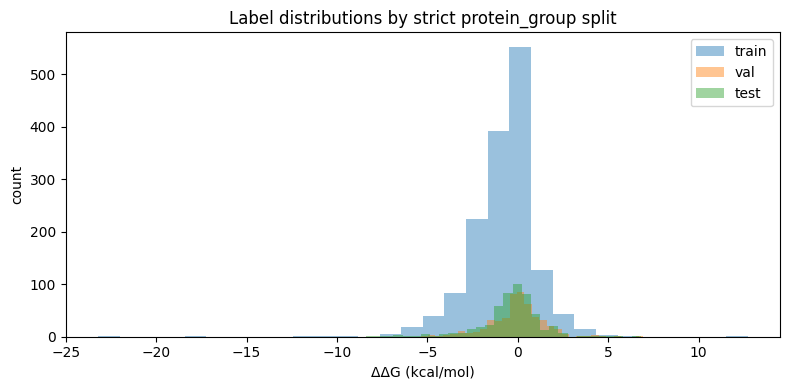

,model,split,rmse,mae,r,y_true_std,y_pred_std,pred_std_ratio,y_pred_min,y_pred_max
0,Mean baseline,train,1.925377,1.311820,NaN,1.925377,0.000000e+00,0.000000e+00,-0.79175,-0.79175
1,Mean baseline,val,1.679188,1.328118,NaN,1.507921,2.220446e-16,1.472521e-16,-0.79175,-0.79175
2,Mean baseline,test,1.783093,1.278339,NaN,1.734203,2.220446e-16,1.280384e-16,-0.79175,-0.79175


In [11]:
def labels_from_examples(examples):
    return np.array([float(ex.y.view(-1)[0]) for ex in examples], dtype=float)

def pearson_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) < 2 or np.std(y_true) < 1e-12 or np.std(y_pred) < 1e-12:
        return float("nan")
    return float(pearsonr(y_true, y_pred)[0])

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residual = y_pred - y_true
    residual_slope = float(np.polyfit(y_true, residual, 1)[0]) if len(y_true) >= 2 and np.std(y_true) > 1e-12 else float("nan")
    pred_slope = float(np.polyfit(y_true, y_pred, 1)[0]) if len(y_true) >= 2 and np.std(y_true) > 1e-12 else float("nan")
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r": pearson_safe(y_true, y_pred),
        "y_true_std": float(np.std(y_true)),
        "y_pred_std": float(np.std(y_pred)),
        "pred_std_ratio": float(np.std(y_pred) / max(np.std(y_true), 1e-12)),
        "y_pred_min": float(np.min(y_pred)),
        "y_pred_max": float(np.max(y_pred)),
        "pred_vs_true_slope": pred_slope,
        "residual_vs_true_slope": residual_slope,
    }

def metric_row(model_name, split, metrics, extra=None):
    out = {"model": model_name, "split": split}
    out.update({k: v for k, v in metrics.items() if k not in ["y_true", "y_pred"]})
    if extra:
        out.update(extra)
    return out

label_table = pd.DataFrame([
    {"split": "train", **regression_metrics(labels_from_examples(train_ds.examples), labels_from_examples(train_ds.examples))},
    {"split": "val", **regression_metrics(labels_from_examples(val_ds.examples), labels_from_examples(val_ds.examples))},
    {"split": "test", **regression_metrics(labels_from_examples(test_ds.examples), labels_from_examples(test_ds.examples))},
])[["split", "y_true_std", "y_pred_min", "y_pred_max"]]
# Above uses identity only to reuse min/max fields; show a direct summary too.
display(pd.DataFrame([
    {"split": name, "n": len(y), "mean": y.mean(), "std": y.std(), "min": y.min(), "max": y.max()}
    for name, y in [
        ("train", labels_from_examples(train_ds.examples)),
        ("val", labels_from_examples(val_ds.examples)),
        ("test", labels_from_examples(test_ds.examples)),
    ]
]))

plt.figure(figsize=(8, 4))
for name, examples in [("train", train_ds.examples), ("val", val_ds.examples), ("test", test_ds.examples)]:
    plt.hist(labels_from_examples(examples), bins=30, alpha=0.45, label=name)
plt.xlabel("ΔΔG (kcal/mol)")
plt.ylabel("count")
plt.title("Label distributions by strict protein_group split")
plt.legend()
plt.tight_layout()
plt.show()

train_mean = labels_from_examples(train_ds.examples).mean()
baseline_rows = []
for name, examples in [("train", train_ds.examples), ("val", val_ds.examples), ("test", test_ds.examples)]:
    y = labels_from_examples(examples)
    pred = np.full_like(y, train_mean, dtype=float)
    baseline_rows.append(metric_row("Mean baseline", name, regression_metrics(y, pred)))
baseline_table = pd.DataFrame(baseline_rows)
display(baseline_table[["model", "split", "rmse", "mae", "r", "y_true_std", "y_pred_std", "pred_std_ratio", "y_pred_min", "y_pred_max"]])


## 8. Strong tabular baselines on the same split

Small ΔΔG datasets reward engineered features and tree/linear models. These baselines are not throwaways; they tell us whether the GNN is adding value beyond amino acid properties and experimental conditions.


The two feature modes help answer a useful question:

`mutation_only --> how much can we predict from the substitution itself?`

`condition_aware --> how much improves when experimental conditions are included?`

If the condition-aware tabular model wins, that means the experimental context is very important for this dataset.


**Result Interpretation**

The best tabular baseline is `HistGradientBoosting(condition_aware)`, with test RMSE about `1.52` and Pearson r about `0.50`. This result is strong?

In [12]:
def fit_predict_tabular(model, train_frame, val_frame, test_frame, mode):
    X_train, names = tabular_features(train_frame, mode=mode)
    X_val, _ = tabular_features(val_frame, mode=mode)
    X_test, _ = tabular_features(test_frame, mode=mode)
    y_train = train_frame["ddG"].to_numpy(dtype=float)
    model.fit(X_train, y_train)
    return names, {
        "train": (y_train, model.predict(X_train)),
        "val": (val_frame["ddG"].to_numpy(dtype=float), model.predict(X_val)),
        "test": (test_frame["ddG"].to_numpy(dtype=float), model.predict(X_test)),
    }

tabular_results = []
tabular_predictions = {}
for mode in ["mutation_only", "condition_aware"]:
    models = {
        f"Ridge ({mode})": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 13))),
        f"ElasticNet ({mode})": make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], alphas=np.logspace(-3, 1, 9), max_iter=20000, cv=5, random_state=SEED)),
        f"HistGradientBoosting ({mode})": HistGradientBoostingRegressor(max_iter=300, learning_rate=0.04, l2_regularization=0.05, early_stopping=True, random_state=SEED),
    }
    for model_name, model in models.items():
        _, preds = fit_predict_tabular(model, train_ds.frame, val_ds.frame, test_ds.frame, mode=mode)
        tabular_predictions[model_name] = preds
        for split, (y_true, y_pred) in preds.items():
            tabular_results.append(metric_row(model_name, split, regression_metrics(y_true, y_pred), extra={"feature_mode": mode}))

tabular_table = pd.DataFrame(tabular_results)
display(tabular_table[tabular_table["split"].eq("test")][["model", "rmse", "mae", "r", "y_true_std", "y_pred_std", "pred_std_ratio", "pred_vs_true_slope", "residual_vs_true_slope"]].sort_values("rmse"))


,model,rmse,mae,r,y_true_std,y_pred_std,pred_std_ratio,pred_vs_true_slope,residual_vs_true_slope
17,HistGradientBoosting (condition_aware),1.520409,1.066674,0.495882,1.734203,0.791860,0.456613,0.226426,-0.773574
5,ElasticNet (mutation_only),1.647749,1.127611,0.315960,1.734203,0.498972,0.287724,0.090909,-0.909091
8,HistGradientBoosting (mutation_only),1.696529,1.201722,0.311059,1.734203,0.827617,0.477232,0.148448,-0.851552
14,ElasticNet (condition_aware),1.718933,1.325240,0.308271,1.734203,0.921233,0.531214,0.163758,-0.836242
11,Ridge (condition_aware),1.721697,1.333280,0.346447,1.734203,0.996729,0.574748,0.199120,-0.800880
2,Ridge (mutation_only),1.757504,1.326360,0.285610,1.734203,0.830557,0.478928,0.136787,-0.863213


## 9. GNN model and training utilities

All neural models train on standardized ΔΔG using only the training-set mean and standard deviation. Metrics are converted back to kcal/mol for reporting, so RMSE and MAE stay interpretable.

The GNN versions are built as a progression:

`V1 --> local mutation-site difference only`

`V2 --> local mutation-site difference + engineered mutation/condition features`

`V3 --> local difference + global pooled graph difference + engineered features`

`V4 --> structure-only version trained only on real 3D graphs`

Each version is trained with three random seeds. This is important because one lucky seed can make a model look better than it really is. The summary table reports mean and standard deviation across seeds.

In [13]:
class GNNEncoder(nn.Module):
    def __init__(self, node_dim=NODE_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, edge_dim=EDGE_DIM, dropout=DROPOUT):
        super().__init__()
        self.input_proj = nn.Linear(node_dim, hidden_dim)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.dropout = dropout
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINEConv(nn=mlp, edge_dim=edge_dim))
            self.norms.append(nn.LayerNorm(hidden_dim))
    def forward(self, x, edge_index, edge_attr):
        h = self.input_proj(x)
        for conv, norm in zip(self.convs, self.norms):
            h_new = conv(h, edge_index, edge_attr)
            h_new = F.relu(norm(h_new))
            h_new = F.dropout(h_new, p=self.dropout, training=self.training)
            h = h + h_new
        return h

def mutation_site_embeddings(batch, h_wt, h_mut):
    starts = batch.x_wt_ptr[:-1].to(h_wt.device)
    mut_idx = batch.mut_idx.view(-1).to(h_wt.device)
    global_idx = starts + mut_idx
    return h_wt[global_idx], h_mut[global_idx]

class DDGPredictorV1(nn.Module):
    """Minimal local GNN: local_delta only."""
    def __init__(self, node_dim=NODE_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT, edge_dim=EDGE_DIM):
        super().__init__()
        self.encoder = GNNEncoder(node_dim, hidden_dim, num_layers, edge_dim=edge_dim, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, batch):
        h_wt = self.encoder(batch.x_wt, batch.edge_index_wt, batch.edge_attr_wt)
        h_mut = self.encoder(batch.x_mut, batch.edge_index_mut, batch.edge_attr_mut)
        wt_site, mut_site = mutation_site_embeddings(batch, h_wt, h_mut)
        return self.head(mut_site - wt_site).view(-1)

class DDGPredictorV2(nn.Module):
    """Local GNN + condition-aware engineered mutation features."""
    def __init__(self, node_dim=NODE_DIM, mut_feat_dim=MUT_FEAT_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT, edge_dim=EDGE_DIM):
        super().__init__()
        self.encoder = GNNEncoder(node_dim, hidden_dim, num_layers, edge_dim=edge_dim, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim + mut_feat_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
        )
    def forward(self, batch):
        h_wt = self.encoder(batch.x_wt, batch.edge_index_wt, batch.edge_attr_wt)
        h_mut = self.encoder(batch.x_mut, batch.edge_index_mut, batch.edge_attr_mut)
        wt_site, mut_site = mutation_site_embeddings(batch, h_wt, h_mut)
        z = torch.cat([mut_site - wt_site, batch.mut_feats.to(h_wt.device)], dim=1)
        return self.head(z).view(-1)

class DDGPredictorV3(nn.Module):
    """Local + global pooled GNN + condition-aware mutation features."""
    def __init__(self, node_dim=NODE_DIM, mut_feat_dim=MUT_FEAT_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT, edge_dim=EDGE_DIM):
        super().__init__()
        self.encoder = GNNEncoder(node_dim, hidden_dim, num_layers, edge_dim=edge_dim, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(2 * hidden_dim + mut_feat_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
        )
    def forward(self, batch):
        h_wt = self.encoder(batch.x_wt, batch.edge_index_wt, batch.edge_attr_wt)
        h_mut = self.encoder(batch.x_mut, batch.edge_index_mut, batch.edge_attr_mut)
        wt_site, mut_site = mutation_site_embeddings(batch, h_wt, h_mut)
        local_delta = mut_site - wt_site
        global_delta = global_mean_pool(h_mut, batch.x_mut_batch) - global_mean_pool(h_wt, batch.x_wt_batch)
        z = torch.cat([local_delta, global_delta, batch.mut_feats.to(h_wt.device)], dim=1)
        return self.head(z).view(-1)

class DDGPredictorV4(DDGPredictorV3):
    """Structure-only distance-aware GNN. Same head as V3; trained only on true 3D graphs."""
    pass

DDGPredictor = DDGPredictorV1

class GraphListDataset(Dataset):
    def __init__(self, examples):
        super().__init__()
        self.examples = list(examples)
    def len(self):
        return len(self.examples)
    def get(self, idx):
        return self.examples[idx]

def scaled_to_raw(y_scaled):
    return np.asarray(y_scaled, dtype=float) * TARGET_STD + TARGET_MEAN

def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred_scaled = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred_scaled = model(batch)
            y_true.extend(batch.y.view(-1).detach().cpu().numpy())
            y_pred_scaled.extend(pred_scaled.detach().cpu().numpy())
    y_true = np.asarray(y_true, dtype=float)
    y_pred = scaled_to_raw(y_pred_scaled)
    out = regression_metrics(y_true, y_pred)
    out["y_true"] = y_true
    out["y_pred"] = y_pred
    return out

def fit_linear_calibration(val_metrics, target_metrics):
    val_pred = np.asarray(val_metrics["y_pred"], dtype=float)
    val_true = np.asarray(val_metrics["y_true"], dtype=float)
    if len(val_true) < 3 or np.std(val_pred) < 1e-8:
        return None
    lr = LinearRegression().fit(val_pred.reshape(-1, 1), val_true)
    calibrated = lr.predict(np.asarray(target_metrics["y_pred"]).reshape(-1, 1))
    out = regression_metrics(target_metrics["y_true"], calibrated)
    out["calibration_intercept"] = float(lr.intercept_)
    out["calibration_slope"] = float(lr.coef_[0])
    return out

def train_one_seed(model_class, train_examples, val_examples, test_examples, version_name, seed, max_epochs=MAX_EPOCHS, patience=PATIENCE, dropout=DROPOUT, weight_decay=WEIGHT_DECAY, permute_labels=False):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    train_loader_local = make_loader(GraphListDataset(train_examples), shuffle=True)
    val_loader_local = make_loader(GraphListDataset(val_examples), shuffle=False)
    test_loader_local = make_loader(GraphListDataset(test_examples), shuffle=False)
    model = model_class(dropout=dropout).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=weight_decay)
    best_state = None
    best_val_rmse = float("inf")
    best_epoch = 0
    history = []
    shuffled_labels = None
    if permute_labels:
        shuffled_labels = np.array([float(ex.y_scaled.view(-1)[0]) for ex in train_examples], dtype=float)
        np.random.default_rng(seed).shuffle(shuffled_labels)
    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        label_offset = 0
        for batch in train_loader_local:
            batch = batch.to(device)
            opt.zero_grad()
            pred = model(batch)
            target = batch.y_scaled.view(-1)
            if permute_labels:
                n = target.numel()
                target = torch.tensor(shuffled_labels[label_offset:label_offset+n], dtype=torch.float, device=device)
                label_offset += n
            loss = F.mse_loss(pred, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            losses.append(float(loss.detach().cpu()))
        train_m = evaluate_model(model, train_loader_local)
        val_m = evaluate_model(model, val_loader_local)
        history.append({"epoch": epoch, "train_loss_scaled_mse": np.mean(losses), "train_rmse": train_m["rmse"], "train_r": train_m["r"], "val_rmse": val_m["rmse"], "val_r": val_m["r"]})
        if val_m["rmse"] < best_val_rmse:
            best_val_rmse = val_m["rmse"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if epoch == 1 or epoch % 10 == 0:
            print(f"{version_name} seed {seed} ep {epoch:03d} | train RMSE {train_m['rmse']:.3f} r {train_m['r']:+.3f} | val RMSE {val_m['rmse']:.3f} r {val_m['r']:+.3f}")
        if epoch - best_epoch >= patience:
            print(f"{version_name} seed {seed}: early stop at epoch {epoch}; best epoch {best_epoch}")
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    train_m = evaluate_model(model, train_loader_local)
    val_m = evaluate_model(model, val_loader_local)
    test_m = evaluate_model(model, test_loader_local)
    cal_test_m = fit_linear_calibration(val_m, test_m)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {
        "version": version_name,
        "seed": seed,
        "best_epoch": best_epoch,
        "params": n_params,
        "history": pd.DataFrame(history),
        "model": model,
        "train_metrics": train_m,
        "val_metrics": val_m,
        "test_metrics": test_m,
        "calibrated_test_metrics": cal_test_m,
        "train_rmse": train_m["rmse"], "train_mae": train_m["mae"], "train_r": train_m["r"],
        "val_rmse": val_m["rmse"], "val_mae": val_m["mae"], "val_r": val_m["r"],
        "test_rmse": test_m["rmse"], "test_mae": test_m["mae"], "test_r": test_m["r"],
        "test_y_true_std": test_m["y_true_std"], "test_y_pred_std": test_m["y_pred_std"],
        "test_pred_std_ratio": test_m["pred_std_ratio"],
        "test_pred_vs_true_slope": test_m["pred_vs_true_slope"],
        "test_residual_vs_true_slope": test_m["residual_vs_true_slope"],
        "test_y_pred_min": test_m["y_pred_min"], "test_y_pred_max": test_m["y_pred_max"],
    }

def train_repeated(model_class, train_examples, val_examples, test_examples, version_name, seeds=GNN_SEEDS, **kwargs):
    results = []
    for seed in seeds:
        results.append(train_one_seed(model_class, train_examples, val_examples, test_examples, version_name, seed=seed, **kwargs))
    return results

def summarize_seed_results(results):
    rows = []
    for r in results:
        rows.append({k: r[k] for k in [
            "version", "seed", "best_epoch", "params", "train_rmse", "val_rmse", "test_rmse", "test_mae", "test_r",
            "test_y_true_std", "test_y_pred_std", "test_pred_std_ratio", "test_pred_vs_true_slope", "test_residual_vs_true_slope", "test_y_pred_min", "test_y_pred_max"
        ]})
    seed_df = pd.DataFrame(rows)
    agg = seed_df.groupby("version").agg(
        n_seeds=("seed", "count"),
        params=("params", "first"),
        best_epoch_mean=("best_epoch", "mean"),
        train_rmse_mean=("train_rmse", "mean"),
        val_rmse_mean=("val_rmse", "mean"),
        test_rmse_mean=("test_rmse", "mean"),
        test_rmse_std=("test_rmse", "std"),
        test_mae_mean=("test_mae", "mean"),
        test_r_mean=("test_r", "mean"),
        test_r_std=("test_r", "std"),
        test_y_true_std=("test_y_true_std", "mean"),
        test_y_pred_std_mean=("test_y_pred_std", "mean"),
        test_pred_std_ratio_mean=("test_pred_std_ratio", "mean"),
        test_pred_vs_true_slope_mean=("test_pred_vs_true_slope", "mean"),
        test_residual_vs_true_slope_mean=("test_residual_vs_true_slope", "mean"),
    ).reset_index()
    return seed_df, agg


## 10. Prediction-collapse and overfit diagnostics - DEBUGGING/CHECK

This section checks prediction spread using `y_pred_std`, `pred_std_ratio`, and residual slope. Healthy behavior means predictions have a meaningful range. A very small prediction standard deviation means the model is mostly predicting the same value for everything.

The overfit-20 test asks a different question: can the model memorize 20 training examples when regularization is turned off? If yes, the forward pass, target handling, and batching are probably working. If no, there may be a bug in the model or data pipeline.

**Result Interpretation**

The untrained model behaves like a collapsed predictor, which is expected, so ok. The overfit-20 test is the key sanity check: the model reaches about `0.075` RMSE and Pearson r near `0.999` on 20 training examples. That means the model has enough capacity and the forward pass/target handling is working. Its poor performance outside those 20 examples shows the real challenge is generalization, not a broken implementation (yay).

In [14]:
if RUN_DEBUG_OVERFIT:
    def print_metric_block(name, metrics):
        print(name)
        print(f"  RMSE: {metrics['rmse']:.3f}")
        print(f"  MAE:  {metrics['mae']:.3f}")
        print(f"  r:    {metrics['r']:+.3f}")
        print(f"  y_true std: {metrics['y_true_std']:.3f}")
        print(f"  y_pred std: {metrics['y_pred_std']:.3f}")
        print(f"  pred std ratio: {metrics['pred_std_ratio']:.3f}")
        print(f"  pred min/max: {metrics['y_pred_min']:.3f} / {metrics['y_pred_max']:.3f}")
        print(f"  pred-vs-true slope: {metrics['pred_vs_true_slope']:.3f}")
        print(f"  residual-vs-true slope: {metrics['residual_vs_true_slope']:.3f}")

    untrained_model = DDGPredictorV1().to(device)
    for name, loader in [("train", train_loader), ("val", val_loader), ("test", test_loader)]:
        print_metric_block(f"Untrained V1 on {name}", evaluate_model(untrained_model, loader))

    small_examples = train_ds.examples[:20]
    small_loader = make_loader(GraphListDataset(small_examples), batch_size=4, shuffle=True)
    small_eval_loader = make_loader(GraphListDataset(small_examples), batch_size=4, shuffle=False)

    overfit_model = DDGPredictorV3(hidden_dim=64, num_layers=3, dropout=0.0).to(device)
    overfit_opt = torch.optim.AdamW(overfit_model.parameters(), lr=1e-3, weight_decay=0.0)
    for epoch in range(1, OVERFIT_EPOCHS + 1):
        overfit_model.train()
        for batch in small_loader:
            batch = batch.to(device)
            overfit_opt.zero_grad()
            loss = F.mse_loss(overfit_model(batch), batch.y_scaled.view(-1))
            loss.backward()
            overfit_opt.step()
        if epoch == 1 or epoch % 25 == 0:
            m = evaluate_model(overfit_model, small_eval_loader)
            print(f"overfit epoch {epoch:03d} | RMSE {m['rmse']:.3f} | r {m['r']:+.3f} | true std {m['y_true_std']:.3f} | pred std {m['y_pred_std']:.3f}")

    print("\nOverfit model evaluated outside the 20 examples:")
    for name, loader in [("small_20", small_eval_loader), ("full_train", train_loader), ("val", val_loader), ("test", test_loader)]:
        print_metric_block(name, evaluate_model(overfit_model, loader))

else:
    print("Skipped debug overfit check.")

Skipped debug overfit check.


## 11. Optional permutation sanity check

If labels are shuffled and the model still performs well on validation/test, something is leaking. **OFF by default to keep runtime down. (too much compute)**


In [15]:
if RUN_PERMUTATION_CHECK:
    perm_results = train_repeated(
        DDGPredictorV2,
        train_ds.examples,
        val_ds.examples,
        test_ds.examples,
        "Permutation V2",
        seeds=[SEED],
        max_epochs=25,
        patience=5,
        permute_labels=True,
    )
    print_metric_block("Permutation V2 test", perm_results[0]["test_metrics"])
else:
    print("Permutation check skipped. Set RUN_PERMUTATION_CHECK=True to run it.")


Permutation check skipped. Set RUN_PERMUTATION_CHECK=True to run it.


## 12. GNN V1-V3 on all available graphs

V1-V3 are GNNs, but they are not pure 3D GNNs across the full dataset (V4 IS THOUGH). They use the best available graph for each example.

The main things to watch are test RMSE, test Pearson r, and prediction spread. A useful model should beat the mean baseline and avoid collapsing to a narrow horizontal band of predictions.

**Results**
The all-example GNNs beat the mean baseline, so they are learning real signal. V3 is the best of these GNNs by RMSE, around `1.55`, with Pearson r around `0.47`. However, the prediction spread is still smaller than the true label spread, so the GNNs still shrink extreme ΔΔG values toward the center.


In [16]:
def print_metric_block(title, metrics):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    skip_keys = {"y_true", "y_pred"}

    preferred_keys = [
        "rmse",
        "mae",
        "r",
        "y_true_std",
        "y_pred_std",
        "pred_std_ratio",
        "pred_vs_true_slope",
        "residual_vs_true_slope",
        "y_pred_min",
        "y_pred_max",
    ]

    for key in preferred_keys:
        if key in metrics:
            val = metrics[key]
            if isinstance(val, (float, np.floating)):
                print(f"{key:>24}: {val:.4f}")
            else:
                print(f"{key:>24}: {val}")

    other_keys = [k for k in metrics.keys() if k not in preferred_keys and k not in skip_keys]
    for key in other_keys:
        val = metrics[key]
        if isinstance(val, (float, np.floating)):
            print(f"{key:>24}: {val:.4f}")
        else:
            print(f"{key:>24}: {val}")

In [17]:
gnn_seed_results = []
gnn_best_results = []
if RUN_GNN_COMPARISON:
    for model_class, version_name in [
        (DDGPredictorV1, "V1 local_delta available-graph GNN"),
        (DDGPredictorV2, "V2 local_delta + condition feats available-graph GNN"),
        (DDGPredictorV3, "V3 local + global + condition feats available-graph GNN"),
    ]:
        results = train_repeated(model_class, train_ds.examples, val_ds.examples, test_ds.examples, version_name)
        gnn_seed_results.extend(results)
        best = min(results, key=lambda r: r["val_rmse"])
        gnn_best_results.append(best)
        print_metric_block(version_name + " best-seed test", best["test_metrics"])
else:
    print("GNN comparison skipped. Set RUN_GNN_COMPARISON=True to run V1-V3.")

if gnn_seed_results:
    gnn_seed_table, gnn_summary_table = summarize_seed_results(gnn_seed_results)
    display(gnn_seed_table)
    display(gnn_summary_table)


V1 local_delta available-graph GNN seed 42 ep 001 | train RMSE 1.908 r +0.196 | val RMSE 1.697 r +0.242
V1 local_delta available-graph GNN seed 42 ep 010 | train RMSE 1.708 r +0.468 | val RMSE 1.484 r +0.359
V1 local_delta available-graph GNN seed 42: early stop at epoch 16; best epoch 8
V1 local_delta available-graph GNN seed 43 ep 001 | train RMSE 1.897 r +0.247 | val RMSE 1.697 r +0.363
V1 local_delta available-graph GNN seed 43 ep 010 | train RMSE 1.796 r +0.367 | val RMSE 1.479 r +0.439
V1 local_delta available-graph GNN seed 43 ep 020 | train RMSE 1.578 r +0.575 | val RMSE 1.616 r +0.265
V1 local_delta available-graph GNN seed 43: early stop at epoch 23; best epoch 15
V1 local_delta available-graph GNN seed 44 ep 001 | train RMSE 1.884 r +0.277 | val RMSE 1.591 r +0.384
V1 local_delta available-graph GNN seed 44 ep 010 | train RMSE 1.784 r +0.377 | val RMSE 1.397 r +0.480
V1 local_delta available-graph GNN seed 44 ep 020 | train RMSE 1.620 r +0.570 | val RMSE 1.440 r +0.378
V1 lo

,version,seed,best_epoch,params,train_rmse,val_rmse,test_rmse,test_mae,test_r,test_y_true_std,test_y_pred_std,test_pred_std_ratio,test_pred_vs_true_slope,test_residual_vs_true_slope,test_y_pred_min,test_y_pred_max
0,V1 local_delta available-graph GNN,42,8,14833,1.771631,1.484060,1.614399,1.144911,0.410070,1.734203,0.535577,0.308832,0.126643,-0.873357,-2.277564,1.102780
1,V1 local_delta available-graph GNN,43,15,14833,1.717308,1.396003,1.639071,1.102100,0.327671,1.734203,0.566586,0.326713,0.107054,-0.892946,-2.528441,1.565382
2,V1 local_delta available-graph GNN,44,15,14833,1.698285,1.371897,1.592165,1.090757,0.396658,1.734203,0.714554,0.412036,0.163437,-0.836563,-3.272197,1.343785
3,V2 local_delta + condition feats available-gra...,42,5,17905,1.765804,1.427378,1.565790,1.069462,0.439007,1.734203,0.630223,0.363408,0.159539,-0.840461,-2.279007,0.766512
4,V2 local_delta + condition feats available-gra...,43,6,17905,1.714625,1.412420,1.526446,1.047514,0.477877,1.734203,0.731885,0.422029,0.201678,-0.798322,-2.976256,0.937332
5,V2 local_delta + condition feats available-gra...,44,4,17905,1.768543,1.409618,1.571767,1.067863,0.435507,1.734203,0.593455,0.342206,0.149033,-0.850967,-2.235597,0.749648
6,V3 local + global + condition feats available-...,42,4,20209,1.761847,1.394015,1.590558,1.094676,0.400876,1.734203,0.619580,0.357271,0.143221,-0.856779,-2.092183,0.765338
7,V3 local + global + condition feats available-...,43,3,20209,1.825698,1.411301,1.616208,1.101767,0.364555,1.734203,0.567552,0.327269,0.119308,-0.880692,-1.435744,1.137146
8,V3 local + global + condition feats available-...,44,3,20209,1.803620,1.400922,1.620292,1.115061,0.369562,1.734203,0.549553,0.316891,0.117111,-0.882889,-1.600148,0.799645


,version,n_seeds,params,best_epoch_mean,train_rmse_mean,val_rmse_mean,test_rmse_mean,test_rmse_std,test_mae_mean,test_r_mean,test_r_std,test_y_true_std,test_y_pred_std_mean,test_pred_std_ratio_mean,test_pred_vs_true_slope_mean,test_residual_vs_true_slope_mean
0,V1 local_delta available-graph GNN,3,14833,12.666667,1.729075,1.417320,1.615212,0.023464,1.112589,0.378133,0.044213,1.734203,0.605572,0.349194,0.132378,-0.867622
1,V2 local_delta + condition feats available-gra...,3,17905,5.000000,1.749657,1.416472,1.554668,0.024623,1.061613,0.450797,0.023517,1.734203,0.651854,0.375881,0.170083,-0.829917
2,V3 local + global + condition feats available-...,3,20209,3.333333,1.797055,1.402079,1.609020,0.016118,1.103835,0.378331,0.019685,1.734203,0.578895,0.333810,0.126547,-0.873453


## 13. Structure V4 only when coverage is sufficient

V4 is the 3D structure model. It trains only on examples where graph construction has found and mapped a real structure.

This makes V4 cleaner, but it also means V4 may use fewer examples than V1-V3. To avoid making a weak/tiny subset result look more important than it is, the notebook requires at least 30 structure-backed training examples, 10 validation examples, and 10 test examples.

**Results**
V4 ran because there were enough structure-backed examples: `1217` train, `433` validation, and `228` test. Its test Pearson r is strong, around `0.53`, which means the 3D structure model is learning useful signals. Its RMSE, about `1.61` (not the best overall), so we should not claim that 3D clearly wins by every metric.

In [18]:
def structure_examples(examples):
    return [ex for ex in examples if int(ex.has_3d.view(-1)[0]) == 1]

train_struct = structure_examples(train_ds.examples)
val_struct = structure_examples(val_ds.examples)
test_struct = structure_examples(test_ds.examples)
struct_counts = {"train": len(train_struct), "val": len(val_struct), "test": len(test_struct)}
print("Structure-backed counts:", struct_counts)
can_run_v4 = all(struct_counts[k] >= STRUCTURE_MIN_COUNTS[k] for k in STRUCTURE_MIN_COUNTS)

v4_seed_results = []
v4_best_result = None
if RUN_GNN_COMPARISON and can_run_v4:
    v4_seed_results = train_repeated(DDGPredictorV4, train_struct, val_struct, test_struct, "V4 structure-only distance-aware GNN")
    v4_best_result = min(v4_seed_results, key=lambda r: r["val_rmse"])
    print_metric_block("V4 best-seed structure-test", v4_best_result["test_metrics"])
    v4_seed_table, v4_summary_table = summarize_seed_results(v4_seed_results)
    display(v4_seed_table)
    display(v4_summary_table)
else:
    print("V4 skipped.")
    print("Reason: need structure-backed counts >=", STRUCTURE_MIN_COUNTS, "but got", struct_counts)
    print("To try V4, set ALLOW_STRUCTURE_DOWNLOADS=True near the top, keep MAX_NEW_STRUCTURE_DOWNLOADS small, rerun setup through graph construction, then rerun this section.")


Structure-backed counts: {'train': 1217, 'val': 433, 'test': 228}
V4 structure-only distance-aware GNN seed 42 ep 001 | train RMSE 1.860 r +0.289 | val RMSE 1.504 r +0.453
V4 structure-only distance-aware GNN seed 42 ep 010 | train RMSE 1.568 r +0.583 | val RMSE 1.275 r +0.454
V4 structure-only distance-aware GNN seed 42: early stop at epoch 15; best epoch 7
V4 structure-only distance-aware GNN seed 43 ep 001 | train RMSE 1.861 r +0.323 | val RMSE 1.549 r +0.489
V4 structure-only distance-aware GNN seed 43 ep 010 | train RMSE 1.605 r +0.537 | val RMSE 1.204 r +0.517
V4 structure-only distance-aware GNN seed 43: early stop at epoch 18; best epoch 10
V4 structure-only distance-aware GNN seed 44 ep 001 | train RMSE 1.851 r +0.312 | val RMSE 1.479 r +0.475
V4 structure-only distance-aware GNN seed 44 ep 010 | train RMSE 1.626 r +0.526 | val RMSE 1.218 r +0.495
V4 structure-only distance-aware GNN seed 44: early stop at epoch 15; best epoch 7

V4 best-seed structure-test
                   

,version,seed,best_epoch,params,train_rmse,val_rmse,test_rmse,test_mae,test_r,test_y_true_std,test_y_pred_std,test_pred_std_ratio,test_pred_vs_true_slope,test_residual_vs_true_slope,test_y_pred_min,test_y_pred_max
0,V4 structure-only distance-aware GNN,42,7,20209,1.647455,1.208855,1.632399,1.157245,0.539843,1.844085,0.736592,0.399435,0.215632,-0.784368,-2.597232,0.899510
1,V4 structure-only distance-aware GNN,43,10,20209,1.604913,1.204064,1.617544,1.149348,0.529253,1.844085,0.935814,0.507468,0.268579,-0.731421,-3.203032,1.665420
2,V4 structure-only distance-aware GNN,44,7,20209,1.682776,1.207016,1.629657,1.170933,0.523267,1.844085,0.808342,0.438343,0.229370,-0.770630,-2.413721,1.295783


,version,n_seeds,params,best_epoch_mean,train_rmse_mean,val_rmse_mean,test_rmse_mean,test_rmse_std,test_mae_mean,test_r_mean,test_r_std,test_y_true_std,test_y_pred_std_mean,test_pred_std_ratio_mean,test_pred_vs_true_slope_mean,test_residual_vs_true_slope_mean
0,V4 structure-only distance-aware GNN,3,20209,8.0,1.645048,1.206645,1.626533,0.007905,1.159175,0.530788,0.008394,1.844085,0.826916,0.448415,0.237861,-0.762139


## 14. Prediction plots

The scatter plots show predicted ΔΔG versus true ΔΔG. The dashed diagonal line is perfect prediction.

How to read the plots:

- Points close to the diagonal are good predictions.
- A narrow horizontal band means prediction shrinkage or collapse.
- Residuals with a strong downward slope mean the model underpredicts large positive values and overpredicts large negative values.

For this project, the plots are just as important as the table because they show whether the model is learning the full ΔΔG range or mostly predicting values near the center.

A healthy model should not form a narrow horizontal band, and residuals should not show a strong downward slope. rip

**Results**
The best model by full-test RMSE is the condition-aware tree baseline, not the GNN. The best GNN is V3, and the structure-only V4 has the strongest correlation on its structure-backed subset but bad RMSE. CONLCUTION: GNNs learn signals + the 3D model is meaningful, but engineered condition-aware features are still extremely competitive for this dataset.


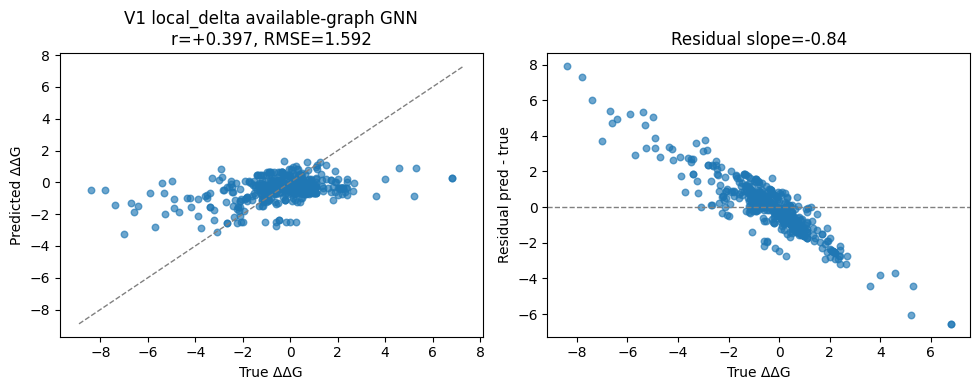

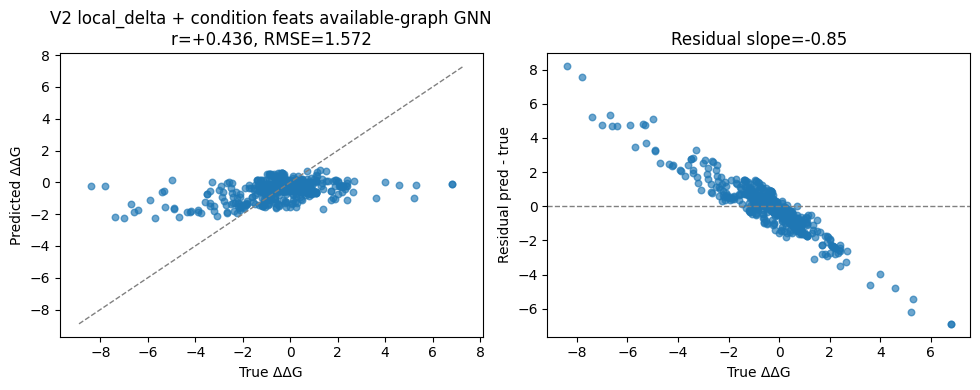

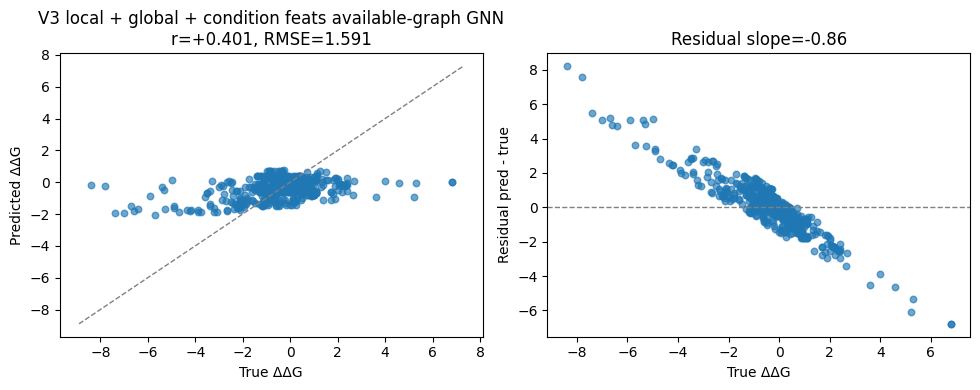

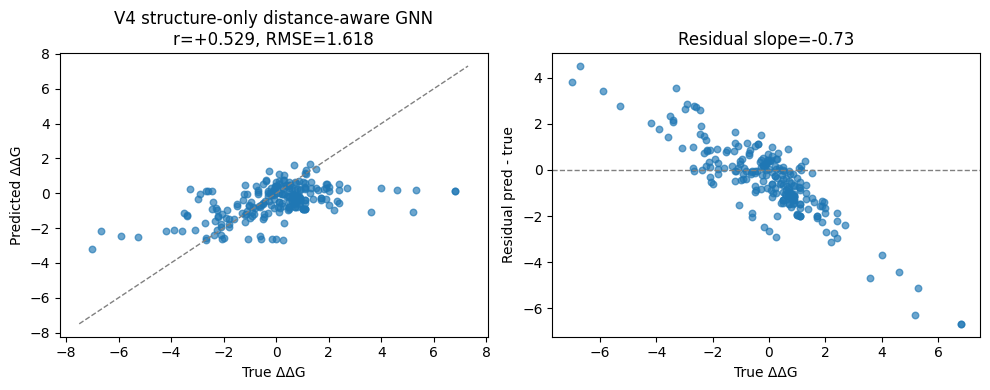

In [19]:
def plot_prediction_scatter(name, metrics):
    y_true, y_pred = metrics["y_true"], metrics["y_pred"]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    lo = float(min(y_true.min(), y_pred.min())) - 0.5
    hi = float(max(y_true.max(), y_pred.max())) + 0.5
    axes[0].scatter(y_true, y_pred, alpha=0.65, s=22)
    axes[0].plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1)
    axes[0].set_xlabel("True ΔΔG")
    axes[0].set_ylabel("Predicted ΔΔG")
    axes[0].set_title(f"{name}\nr={metrics['r']:+.3f}, RMSE={metrics['rmse']:.3f}")
    residuals = y_pred - y_true
    axes[1].scatter(y_true, residuals, alpha=0.65, s=22)
    axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[1].set_xlabel("True ΔΔG")
    axes[1].set_ylabel("Residual pred - true")
    axes[1].set_title(f"Residual slope={metrics['residual_vs_true_slope']:.2f}")
    plt.tight_layout()
    plt.show()

for r in gnn_best_results:
    plot_prediction_scatter(r["version"], r["test_metrics"])
if v4_best_result is not None:
    plot_prediction_scatter(v4_best_result["version"], v4_best_result["test_metrics"])


## 15. Final comparison table

**Main result summary.** It combines the mean baseline, tabular baselines, all-example GNNs, and the structure-only V4 model.

The most important columns are:

- `test_rmse_mean`: lower is better, measured in kcal/mol.
- `test_r_mean`: higher is better, measures ranking/correlation.
- `test_pred_std_ratio_mean`: prediction spread compared with true label spread.
- `test_residual_vs_true_slope_mean`: how strongly errors depend on the true ΔΔG value.

In [20]:
comparison_rows = []
for _, row in baseline_table[baseline_table["split"].eq("test")].iterrows():
    comparison_rows.append({
        "model": row["model"], "family": "baseline", "n_seeds": 1,
        "test_rmse_mean": row["rmse"], "test_rmse_std": np.nan,
        "test_mae_mean": row["mae"], "test_r_mean": row["r"], "test_r_std": np.nan,
        "test_y_true_std": row["y_true_std"], "test_y_pred_std_mean": row["y_pred_std"],
        "test_pred_std_ratio_mean": row["pred_std_ratio"],
        "test_pred_vs_true_slope_mean": row["pred_vs_true_slope"],
        "test_residual_vs_true_slope_mean": row["residual_vs_true_slope"],
    })
for _, row in tabular_table[tabular_table["split"].eq("test")].iterrows():
    comparison_rows.append({
        "model": row["model"], "family": "tabular", "n_seeds": 1,
        "test_rmse_mean": row["rmse"], "test_rmse_std": np.nan,
        "test_mae_mean": row["mae"], "test_r_mean": row["r"], "test_r_std": np.nan,
        "test_y_true_std": row["y_true_std"], "test_y_pred_std_mean": row["y_pred_std"],
        "test_pred_std_ratio_mean": row["pred_std_ratio"],
        "test_pred_vs_true_slope_mean": row["pred_vs_true_slope"],
        "test_residual_vs_true_slope_mean": row["residual_vs_true_slope"],
    })
if gnn_seed_results:
    _, gnn_summary_table = summarize_seed_results(gnn_seed_results)
    for _, row in gnn_summary_table.iterrows():
        d = row.to_dict()
        comparison_rows.append({"model": d.pop("version"), "family": "available_graph_gnn", **d})
if v4_seed_results:
    _, v4_summary_table = summarize_seed_results(v4_seed_results)
    for _, row in v4_summary_table.iterrows():
        d = row.to_dict()
        comparison_rows.append({"model": d.pop("version"), "family": "structure_gnn", **d})

comparison_table = pd.DataFrame(comparison_rows)
comparison_table = comparison_table.sort_values("test_rmse_mean")
display(comparison_table)

print("Collapse flags:")
for _, row in comparison_table.iterrows():
    status = "COLLAPSED" if row["test_pred_std_ratio_mean"] < 0.15 else "non-collapsed/partly spread"
    print(f"{row['model']}: pred std ratio {row['test_pred_std_ratio_mean']:.3f}, residual slope {row['test_residual_vs_true_slope_mean']:.3f} -> {status}")


,model,family,n_seeds,test_rmse_mean,test_rmse_std,test_mae_mean,test_r_mean,test_r_std,test_y_true_std,test_y_pred_std_mean,test_pred_std_ratio_mean,test_pred_vs_true_slope_mean,test_residual_vs_true_slope_mean,params,best_epoch_mean,train_rmse_mean,val_rmse_mean
6,HistGradientBoosting (condition_aware),tabular,1,1.520409,NaN,1.066674,0.495882,NaN,1.734203,7.918596e-01,4.566130e-01,2.264263e-01,-0.773574,NaN,NaN,NaN,NaN
8,V2 local_delta + condition feats available-gra...,available_graph_gnn,3,1.554668,0.024623,1.061613,0.450797,0.023517,1.734203,6.518543e-01,3.758812e-01,1.700834e-01,-0.829917,17905.0,5.000000,1.749657,1.416472
9,V3 local + global + condition feats available-...,available_graph_gnn,3,1.609020,0.016118,1.103835,0.378331,0.019685,1.734203,5.788949e-01,3.338103e-01,1.265466e-01,-0.873453,20209.0,3.333333,1.797055,1.402079
7,V1 local_delta available-graph GNN,available_graph_gnn,3,1.615212,0.023464,1.112589,0.378133,0.044213,1.734203,6.055724e-01,3.491935e-01,1.323781e-01,-0.867622,14833.0,12.666667,1.729075,1.417320
10,V4 structure-only distance-aware GNN,structure_gnn,3,1.626533,0.007905,1.159175,0.530788,0.008394,1.844085,8.269159e-01,4.484153e-01,2.378605e-01,-0.762139,20209.0,8.000000,1.645048,1.206645
2,ElasticNet (mutation_only),tabular,1,1.647749,NaN,1.127611,0.315960,NaN,1.734203,4.989719e-01,2.877240e-01,9.090935e-02,-0.909091,NaN,NaN,NaN,NaN
3,HistGradientBoosting (mutation_only),tabular,1,1.696529,NaN,1.201722,0.311059,NaN,1.734203,8.276173e-01,4.772321e-01,1.484475e-01,-0.851552,NaN,NaN,NaN,NaN
5,ElasticNet (condition_aware),tabular,1,1.718933,NaN,1.325240,0.308271,NaN,1.734203,9.212325e-01,5.312138e-01,1.637577e-01,-0.836242,NaN,NaN,NaN,NaN
4,Ridge (condition_aware),tabular,1,1.721697,NaN,1.333280,0.346447,NaN,1.734203,9.967293e-01,5.747478e-01,1.991195e-01,-0.800880,NaN,NaN,NaN,NaN
1,Ridge (mutation_only),tabular,1,1.757504,NaN,1.326360,0.285610,NaN,1.734203,8.305575e-01,4.789275e-01,1.367865e-01,-0.863213,NaN,NaN,NaN,NaN


Collapse flags:
HistGradientBoosting (condition_aware): pred std ratio 0.457, residual slope -0.774 -> non-collapsed/partly spread
V2 local_delta + condition feats available-graph GNN: pred std ratio 0.376, residual slope -0.830 -> non-collapsed/partly spread
V3 local + global + condition feats available-graph GNN: pred std ratio 0.334, residual slope -0.873 -> non-collapsed/partly spread
V1 local_delta available-graph GNN: pred std ratio 0.349, residual slope -0.868 -> non-collapsed/partly spread
V4 structure-only distance-aware GNN: pred std ratio 0.448, residual slope -0.762 -> non-collapsed/partly spread
ElasticNet (mutation_only): pred std ratio 0.288, residual slope -0.909 -> non-collapsed/partly spread
HistGradientBoosting (mutation_only): pred std ratio 0.477, residual slope -0.852 -> non-collapsed/partly spread
ElasticNet (condition_aware): pred std ratio 0.531, residual slope -0.836 -> non-collapsed/partly spread
Ridge (condition_aware): pred std ratio 0.575, residual slope -

Literature context:

- ProThermDB documents the thermodynamic mutation data and the importance of experimental conditions: https://pmc.ncbi.nlm.nih.gov/articles/PMC7778892/
- ThermoMPNN motivates local structural neighborhoods and learned structural features: https://pmc.ncbi.nlm.nih.gov/articles/PMC10402116/
- ThermoNet shows why real structure matters and why bias toward the mean is a known ΔΔG challenge: https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1008291


## 16. Save 

In [21]:
if SAVE_RESULTS:
    comparison_table.to_csv(RESULTS_DIR / f"model_comparison_{RUN_TAG}.csv", index=False)

    if "baseline_table" in globals():
        baseline_table.to_csv(RESULTS_DIR / f"baseline_results_{RUN_TAG}.csv", index=False)

    if "tabular_table" in globals():
        tabular_table.to_csv(RESULTS_DIR / f"tabular_results_{RUN_TAG}.csv", index=False)

    if "gnn_seed_table" in globals():
        gnn_seed_table.to_csv(RESULTS_DIR / f"gnn_seed_results_{RUN_TAG}.csv", index=False)

    if "gnn_summary_table" in globals():
        gnn_summary_table.to_csv(RESULTS_DIR / f"gnn_summary_results_{RUN_TAG}.csv", index=False)

    if "v4_seed_table" in globals():
        v4_seed_table.to_csv(RESULTS_DIR / f"v4_seed_results_{RUN_TAG}.csv", index=False)

    if "v4_summary_table" in globals():
        v4_summary_table.to_csv(RESULTS_DIR / f"v4_summary_results_{RUN_TAG}.csv", index=False)

    print("Saved summary result tables.")

Saved summary result tables.


In [22]:
def example_metadata_frame(examples, split):
    rows = []
    for ex in examples:
        rows.append({
            "split": split,
            "row_id": int(ex.row_id.view(-1)[0]),
            "protein": getattr(ex, "protein", ""),
            "protein_group": getattr(ex, "protein_group", ""),
            "mutation": getattr(ex, "mutation", ""),
            "graph_source": getattr(ex, "graph_source", "unknown"),
            "has_3d": int(ex.has_3d.view(-1)[0]),
            "y_true_from_graph": float(ex.y.view(-1)[0]),
        })
    meta = pd.DataFrame(rows)
    keep_cols = [
        "row_id", "PROTEIN", "UniProt_ID", "PDB_wild", "PDB_Chain_Mutation",
        "MUTATION", "WT_AA", "POSITION", "MUT_AA", "ddG",
        "pH_num", "temp_C_num", "ASA_num", "ASA_missing",
        "mutation_basis", "protein_group", "mutation_key", "split",
    ]
    keep_cols = [c for c in keep_cols if c in df.columns]
    meta = meta.merge(df[keep_cols], on="row_id", how="left", suffixes=("", "_df"))
    return meta

def gnn_prediction_frame(result, examples, split):
    loader = make_loader(GraphListDataset(examples), shuffle=False)
    metrics = evaluate_model(result["model"], loader)
    meta = example_metadata_frame(examples, split)
    meta["model"] = result["version"]
    meta["seed"] = result["seed"]
    meta["best_epoch"] = result["best_epoch"]
    meta["y_true"] = metrics["y_true"]
    meta["y_pred"] = metrics["y_pred"]
    meta["residual"] = meta["y_pred"] - meta["y_true"]
    return meta

def tabular_prediction_frame(model_name, preds, split, frame):
    y_true, y_pred = preds[split]
    keep_cols = [
        "row_id", "PROTEIN", "UniProt_ID", "PDB_wild", "PDB_Chain_Mutation",
        "MUTATION", "WT_AA", "POSITION", "MUT_AA", "ddG",
        "pH_num", "temp_C_num", "ASA_num", "ASA_missing",
        "mutation_basis", "protein_group", "mutation_key", "split",
    ]
    keep_cols = [c for c in keep_cols if c in frame.columns]
    out = frame[keep_cols].reset_index(drop=True).copy()
    out["model"] = model_name
    out["seed"] = np.nan
    out["best_epoch"] = np.nan
    out["graph_source"] = "tabular_no_graph"
    out["has_3d"] = np.nan
    out["y_true"] = y_true
    out["y_pred"] = y_pred
    out["residual"] = out["y_pred"] - out["y_true"]
    return out

prediction_frames = []

if "tabular_predictions" in globals():
    split_to_frame = {"train": train_ds.frame, "val": val_ds.frame, "test": test_ds.frame}
    for model_name, preds in tabular_predictions.items():
        for split, frame in split_to_frame.items():
            prediction_frames.append(tabular_prediction_frame(model_name, preds, split, frame))

if "gnn_best_results" in globals():
    split_to_examples = {"train": train_ds.examples, "val": val_ds.examples, "test": test_ds.examples}
    for result in gnn_best_results:
        for split, examples in split_to_examples.items():
            prediction_frames.append(gnn_prediction_frame(result, examples, split))

if "v4_best_result" in globals() and v4_best_result is not None:
    split_to_examples = {"train": train_struct, "val": val_struct, "test": test_struct}
    for split, examples in split_to_examples.items():
        prediction_frames.append(gnn_prediction_frame(v4_best_result, examples, split))

all_predictions = pd.concat(prediction_frames, ignore_index=True)
all_predictions.to_csv(RESULTS_DIR / f"all_predictions_{RUN_TAG}.csv", index=False)

print("Saved row-level predictions:", all_predictions.shape)
display(all_predictions.head())

Saved row-level predictions: (24522, 31)


,row_id,PROTEIN,UniProt_ID,PDB_wild,PDB_Chain_Mutation,MUTATION,WT_AA,POSITION,MUT_AA,ddG,...,graph_source,has_3d,y_true,y_pred,residual,protein,mutation,y_true_from_graph,protein_group_df,split_df
0,0,Villin-1,P02640,1YRF,-,D44N (UniProt),D,44,N,1.73,...,tabular_no_graph,NaN,1.73,0.533921,-1.196079,NaN,NaN,NaN,NaN,NaN
1,1,Villin-1,P02640,1YRF,-,E795Q (UniProt),E,795,Q,1.90,...,tabular_no_graph,NaN,1.90,0.201547,-1.698453,NaN,NaN,NaN,NaN,NaN
2,2,Villin-1,P02640,1YRF,-,D796N (UniProt),D,796,N,1.61,...,tabular_no_graph,NaN,1.61,0.063310,-1.546690,NaN,NaN,NaN,NaN,NaN
3,3,Villin-1,P02640,1YRF,-,E822Q (UniProt),E,822,Q,1.60,...,tabular_no_graph,NaN,1.60,0.196085,-1.403915,NaN,NaN,NaN,NaN,NaN
4,4,Villin-1,P02640,1YRF,-,D44N (UniProt),D,44,N,-0.46,...,tabular_no_graph,NaN,-0.46,0.533921,0.993921,NaN,NaN,NaN,NaN,NaN


In [23]:
## ASA/buried exposed ablation
def assign_asa_context(frame):
    out = frame.copy()

    unique_test = (
        out.loc[(out["split"] == "test") & out["ASA_num"].notna(), ["row_id", "ASA_num"]]
        .drop_duplicates("row_id")
    )

    if len(unique_test) < 20:
        out["asa_context"] = "ASA unavailable/too sparse"
        return out, np.nan, np.nan

    buried_cut = unique_test["ASA_num"].quantile(0.33)
    exposed_cut = unique_test["ASA_num"].quantile(0.67)

    out["asa_context"] = "middle/unknown"
    out.loc[out["ASA_num"].notna() & (out["ASA_num"] <= buried_cut), "asa_context"] = "buried/low_ASA"
    out.loc[out["ASA_num"].notna() & (out["ASA_num"] >= exposed_cut), "asa_context"] = "exposed/high_ASA"
    out.loc[out["ASA_num"].isna(), "asa_context"] = "ASA_missing"

    return out, buried_cut, exposed_cut

all_predictions_with_context, buried_cut, exposed_cut = assign_asa_context(all_predictions)

stratified_rows = []
for (model_name, context), group in all_predictions_with_context[
    (all_predictions_with_context["split"] == "test") &
    (all_predictions_with_context["asa_context"].isin(["buried/low_ASA", "exposed/high_ASA"]))
].groupby(["model", "asa_context"]):

    if len(group) < 3:
        continue

    metrics = regression_metrics(group["y_true"], group["y_pred"])
    stratified_rows.append({
        "model": model_name,
        "asa_context": context,
        "n": len(group),
        "asa_buried_cut": buried_cut,
        "asa_exposed_cut": exposed_cut,
        "rmse": metrics["rmse"],
        "mae": metrics["mae"],
        "r": metrics["r"],
        "pred_std_ratio": metrics["pred_std_ratio"],
        "pred_vs_true_slope": metrics["pred_vs_true_slope"],
        "residual_vs_true_slope": metrics["residual_vs_true_slope"],
    })

asa_stratified_table = pd.DataFrame(stratified_rows).sort_values(["model", "asa_context"])
asa_stratified_table.to_csv(RESULTS_DIR / f"asa_stratified_results_{RUN_TAG}.csv", index=False)
all_predictions_with_context.to_csv(RESULTS_DIR / f"all_predictions_with_context_{RUN_TAG}.csv", index=False)

display(asa_stratified_table)
print("Saved ASA-stratified ablation table.")

,model,asa_context,n,asa_buried_cut,asa_exposed_cut,rmse,mae,r,pred_std_ratio,pred_vs_true_slope,residual_vs_true_slope
0,ElasticNet (condition_aware),buried/low_ASA,100,10.41,38.86,2.147217,1.629492,0.678783,0.174274,0.118294,-0.881706
1,ElasticNet (condition_aware),exposed/high_ASA,112,10.41,38.86,1.252307,1.005980,0.309048,0.365644,0.113002,-0.886998
2,ElasticNet (mutation_only),buried/low_ASA,100,10.41,38.86,2.225455,1.660911,0.585045,0.212930,0.124574,-0.875426
3,ElasticNet (mutation_only),exposed/high_ASA,112,10.41,38.86,1.283012,1.029853,0.182127,0.448081,0.081608,-0.918392
4,HistGradientBoosting (condition_aware),buried/low_ASA,100,10.41,38.86,1.890873,1.472266,0.650338,0.452991,0.294598,-0.705402
5,HistGradientBoosting (condition_aware),exposed/high_ASA,112,10.41,38.86,1.281524,1.023090,0.206884,0.410482,0.084922,-0.915078
6,HistGradientBoosting (mutation_only),buried/low_ASA,100,10.41,38.86,2.280484,1.788855,0.355343,0.437717,0.155540,-0.844460
7,HistGradientBoosting (mutation_only),exposed/high_ASA,112,10.41,38.86,1.533641,1.217974,0.207508,0.690800,0.143346,-0.856654
8,Ridge (condition_aware),buried/low_ASA,100,10.41,38.86,2.054335,1.534758,0.669067,0.259976,0.173941,-0.826059
9,Ridge (condition_aware),exposed/high_ASA,112,10.41,38.86,1.258148,0.994566,0.185138,0.512003,0.094791,-0.905209


Saved ASA-stratified ablation table.


In [24]:
history_frames = []

if "gnn_seed_results" in globals():
    for result in gnn_seed_results:
        h = result["history"].copy()
        h["version"] = result["version"]
        h["seed"] = result["seed"]
        history_frames.append(h)

if "v4_seed_results" in globals():
    for result in v4_seed_results:
        h = result["history"].copy()
        h["version"] = result["version"]
        h["seed"] = result["seed"]
        history_frames.append(h)

if history_frames:
    training_history_table = pd.concat(history_frames, ignore_index=True)
    training_history_table.to_csv(RESULTS_DIR / f"training_history_{RUN_TAG}.csv", index=False)
    display(training_history_table.head())
    print("Saved training history.")

,epoch,train_loss_scaled_mse,train_rmse,train_r,val_rmse,val_r,version,seed
0,1,1.000951,1.908359,0.195845,1.696782,0.242222,V1 local_delta available-graph GNN,42
1,2,0.982569,1.884579,0.260788,1.647994,0.325338,V1 local_delta available-graph GNN,42
2,3,0.960587,1.861152,0.284687,1.585183,0.371855,V1 local_delta available-graph GNN,42
3,4,0.928894,1.839868,0.312367,1.543042,0.375249,V1 local_delta available-graph GNN,42
4,5,0.913714,1.824665,0.329301,1.506449,0.390158,V1 local_delta available-graph GNN,42


Saved training history.


In [25]:
df.to_csv(RESULTS_DIR / f"cleaned_data_with_splits_{RUN_TAG}.csv", index=False)

if "coverage_table" in globals():
    coverage_table.to_csv(RESULTS_DIR / f"graph_coverage_{RUN_TAG}.csv", index=False)

if "label_table" in globals():
    label_table.to_csv(RESULTS_DIR / f"label_distribution_{RUN_TAG}.csv", index=False)

print("Saved cleaned data, graph coverage, and label distribution.")

Saved cleaned data, graph coverage, and label distribution.


In [26]:
# JSON export for HTML website
def aa_from_node_features(x_row):
    aa_idx = int(np.argmax(x_row[:len(AA_LIST)]))
    return AA_LIST[aa_idx]

def export_contact_graph_example(examples, split_name, out_path):
    candidates = [ex for ex in examples if int(ex.has_3d.view(-1)[0]) == 1]
    if len(candidates) == 0:
        candidates = list(examples)

    ex = candidates[0]
    n = ex.x_wt.shape[0]
    mut_idx = int(ex.mut_idx.view(-1)[0])
    row_id = int(ex.row_id.view(-1)[0])

    row = df[df["row_id"] == row_id].iloc[0].to_dict()

    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    nodes = []
    x_wt_np = ex.x_wt.detach().cpu().numpy()

    for i in range(n):
        aa = aa_from_node_features(x_wt_np[i])
        nodes.append({
            "id": int(i),
            "aa": aa,
            "is_mutation_site": bool(i == mut_idx),
            "x": float(np.cos(theta[i])),
            "y": float(np.sin(theta[i])),
        })

    edge_index = ex.edge_index_wt.detach().cpu().numpy()
    seen = set()
    edges = []
    for a, b in edge_index.T:
        a, b = int(a), int(b)
        if a == b:
            continue
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        edges.append({"source": key[0], "target": key[1]})

    prediction_lookup = {}
    if "all_predictions" in globals():
        pred_rows = all_predictions[
            (all_predictions["row_id"] == row_id) &
            (all_predictions["split"] == split_name)
        ]
        for _, pred_row in pred_rows.iterrows():
            prediction_lookup[str(pred_row["model"])] = {
                "y_true": float(pred_row["y_true"]),
                "y_pred": float(pred_row["y_pred"]),
                "residual": float(pred_row["residual"]),
            }

    payload = {
        "protein": str(row.get("PROTEIN", "")),
        "protein_group": str(row.get("protein_group", "")),
        "mutation": str(row.get("MUTATION", "")),
        "wt_aa": str(row.get("WT_AA", "")),
        "mut_aa": str(row.get("MUT_AA", "")),
        "position": int(row.get("POSITION", -1)),
        "true_ddG": float(row.get("ddG", np.nan)),
        "graph_source": getattr(ex, "graph_source", "unknown"),
        "split": split_name,
        "model_predictions": prediction_lookup,
        "nodes": nodes,
        "edges": edges,
    }

    with open(out_path, "w") as f:
        json.dump(payload, f, indent=2)

    print("Saved graph explorer JSON:", out_path)
    print("Example:", payload["protein"], payload["mutation"], payload["graph_source"], "nodes:", len(nodes), "edges:", len(edges))

if "test_ds" in globals():
    export_contact_graph_example(test_ds.examples, "test", FIGURES_DIR / f"contact_graph_example_{RUN_TAG}.json")

Saved graph explorer JSON: assets/contact_graph_example_final_main.json
Example: Class A sortase SrtA M155V (UniProt) structure nodes: 64 edges: 285


In [27]:
model_ranking = comparison_table.copy()
model_ranking["rank_by_rmse"] = model_ranking["test_rmse_mean"].rank(method="min", ascending=True)
model_ranking["rank_by_r"] = model_ranking["test_r_mean"].rank(method="min", ascending=False)
model_ranking.to_csv(RESULTS_DIR / f"model_ranking_{RUN_TAG}.csv", index=False)
display(model_ranking[["model", "family", "rank_by_rmse", "rank_by_r", "test_rmse_mean", "test_r_mean"]])

,model,family,rank_by_rmse,rank_by_r,test_rmse_mean,test_r_mean
6,HistGradientBoosting (condition_aware),tabular,1.0,2.0,1.520409,0.495882
8,V2 local_delta + condition feats available-gra...,available_graph_gnn,2.0,3.0,1.554668,0.450797
9,V3 local + global + condition feats available-...,available_graph_gnn,3.0,4.0,1.609020,0.378331
7,V1 local_delta available-graph GNN,available_graph_gnn,4.0,5.0,1.615212,0.378133
10,V4 structure-only distance-aware GNN,structure_gnn,5.0,1.0,1.626533,0.530788
2,ElasticNet (mutation_only),tabular,6.0,7.0,1.647749,0.315960
3,HistGradientBoosting (mutation_only),tabular,7.0,8.0,1.696529,0.311059
5,ElasticNet (condition_aware),tabular,8.0,9.0,1.718933,0.308271
4,Ridge (condition_aware),tabular,9.0,6.0,1.721697,0.346447
1,Ridge (mutation_only),tabular,10.0,10.0,1.757504,0.285610
